In [1]:
# ==============================================================================
# 0. Environment Setup & Visual Configuration
# ==============================================================================
!pip install --quiet astroML scikit-learn scipy matplotlib numpy

import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.decomposition import PCA

# Enable high-resolution plots for Retina / 4K displays
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

# Standardize plot styling across the entire notebook (Astrostatistics style)
plt.rcParams.update({
    'figure.figsize': (9, 5),
    'figure.dpi': 110,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'legend.frameon': True,
    'lines.linewidth': 2.0
})

# Fix random seed for computational reproducibility
np.random.seed(42)

print("✨ Environment configured: Packages installed, high-DPI graphics enabled, and seed set to 42.")

✨ Environment configured: Packages installed, high-DPI graphics enabled, and seed set to 42.


# Principal Component Analysis (PCA) & Dimensionality Reduction in Astronomy

---

### 📋 Table of Contents
1. [The Challenge of High-Dimensional Data in Astronomy](#1-curse)
2. [Geometric Intuition: Direction of Maximal Variance](#2-intuition)
3. [Mathematical Derivation: Covariance, Lagrange Multipliers & EVD](#3-derivation)
4. [Efficient Computation: Singular Value Decomposition (SVD) vs. EVD](#4-svd)
5. [Numerical Verification: SVD vs. EVD vs. Scikit-Learn](#5-verification)
6. [Data Preprocessing & Whitening in Astronomy](#6-preprocessing)
7. [Astronomical Case Study: SDSS Galaxy Eigenspectra](#7-sdss)
8. [Scree Plots, Eigenvalues & Information Compression](#8-scree)
9. [Physical Interpretation of Eigenspectra (Continuum vs. Emission Lines)](#9-physics)
10. [Choosing the Truncation Level $r$ (Variance Bounds & Knee Detection)](#10-truncation)
11. [PCA with Missing & Censored Data (Gappy PCA / Connolly & Szalay)](#11-gappy)
12. [Scaling to Massive Datasets: Online / Incremental PCA](#12-scaling)
13. [Hands-On Conceptual Exercises & Astronomical Challenges](#13-exercises)

---

<div style="border-left: 5px solid #0096c7; padding: 12px 18px; margin: 15px 0; background: rgba(0, 150, 199, 0.1); border-radius: 4px;">
    <h3 style="margin-top: 0;">🎯 Class Learning Objectives</h3>
    <ul>
        <li><b>Geometric & Algebraic Intuition:</b> Understand PCA as an optimal orthogonal coordinate rotation that aligns with directions of maximal variance and diagonalizes the covariance matrix.</li>
        <li><b>Equivalence of Formulations:</b> Prove the mathematical equivalence between the <b>Eigenvalue Decomposition (EVD)</b> of the sample covariance matrix and the <b>Singular Value Decomposition (SVD)</b> of the centered data matrix.</li>
        <li><b>Astronomical Data Compression:</b> Apply PCA to 4,000 SDSS galaxy spectra, compressing a 1,000-wavelength-bin space by a factor of 100 while retaining &gt;94% of physical information.</li>
        <li><b>Physical Diagnostics:</b> Distinguish broad stellar population continuum shapes (first components) from localized nebular emission lines ([OII], [OIII], H&alpha;, H&beta;).</li>
        <li><b>Handling Real-World Imperfections:</b> Formulate <i>Gappy PCA</i> to reconstruct masked sky lines and cosmic ray hits, and examine <i>Online PCA</i> for streaming Big Data surveys (Rubin Observatory / LSST).</li>
    </ul>
</div>

<div style="border-left: 5px solid #2b9348; padding: 12px 18px; margin: 15px 0; background: rgba(43, 147, 72, 0.1); border-radius: 4px;">
    <h4 style="margin-top: 0;">🌌 Why is Dimensionality Reduction Essential in Astronomy?</h4>
    Modern astronomical surveys (SDSS, DESI, Gaia, Vera C. Rubin LSST, JWST) capture millions of celestial targets across hundreds to thousands of observables (multi-band flux, spectral wavelength bins, morphology parameters). However, high-dimensional spaces suffer from the <b>Curse of Dimensionality</b>: volume grows exponentially, making the space mostly empty, distances Euclideanly uninformative, and parametric modeling computationally prohibitive. Dimensionality reduction discovers the lower-dimensional intrinsic manifold where the astrophysics actually lives.
</div>

<a id="1-curse"></a>
## 1. The Challenge of High-Dimensional Data in Astronomy

> *"A mind that is stretched by a new idea can never go back to its original dimensions."*  
> — **Oliver Wendell Holmes**

The dramatic increase in data available from a new generation of astronomical surveys is not just about sample size ($N$), but also feature dimensionality ($K$). For example, with SDSS imaging data we can measure arbitrary numbers of properties for any detected source (progressive moments of pixel flux distributions, multi-band colors, shape profiles). From an efficiency standpoint, we want to measure only properties that directly correlate with the physical questions we want to answer. In practice, however, we do not know the optimal set of functions or basis sets a priori.

<div align="center" style="margin: 20px 0;">
  <img src="Big-Data-3V-characteristics-in-astronomical-sky-surveys.png" alt="Big Data in Astronomy" style="width: 100%; max-width: 850px; border-radius: 8px; box-shadow: 0 4px 16px rgba(0,0,0,0.15);">
  <p style="font-size: 0.9em; color: #666; margin-top: 6px;"><i>Figure: The 3V/4V challenges (Volume, Variety, Velocity, Value) in modern wide-field astronomical sky surveys.</i></p>
</div>

*Reference:* [STScI Big Data SDT Report](https://archive.stsci.edu/reports/BigDataSDTReport_Final.pdf)

<div style="border-left: 5px solid #e09f3e; padding: 12px 18px; margin: 15px 0; background: rgba(224, 159, 62, 0.12); border-radius: 4px;">
    <h4 style="margin-top: 0;">⚠️ The Curse of Dimensionality: Hypersphere Volume</h4>
    Consider the SDSS photometric catalogue comprising 357 million sources, each with up to 448 measured attributes. In a unit hypercube $[-1, 1]^D$, the ratio of the volume of an inscribed hypersphere of radius 1 to the volume of the hypercube is:
    $$\frac{V_{\text{sphere}}(D)}{V_{\text{cube}}(D)} = \frac{\frac{\pi^{D/2}}{\Gamma(D/2 + 1)}}{2^D} \xrightarrow{D \to \infty} 0$$
    For $D = 10$, this ratio is already only one part in $1.4 \times 10^5$. In high dimensions, almost the entire volume of space resides in the outer corners of the bounding box! Almost all sample points are near the boundary and far from each other, rendering nearest-neighbor distance metrics and density estimation unreliable unless dimensionality is reduced.
</div>

Here we will use SDSS galaxy spectra as our primary astronomical proxy. While a single spectrum is recorded as flux across $D = 1,000$ wavelength bins (a vector in $\mathbb{R}^D$), the physical processes governing galaxy formation (stellar mass, star-formation history, metallicity, dust extinction, active galactic nuclei) have far fewer degrees of freedom. PCA enables us to discover this compact intrinsic subspace.

/home/mardom/anaconda3/envs/transformers/lib/python3.14/site-packages/astroML/linear_model/linear_regression_errors.py:10: UserWarning: LinearRegressionwithErrors requires PyMC3 to be installed
  warnings.warn('LinearRegressionwithErrors requires PyMC3 to be installed')


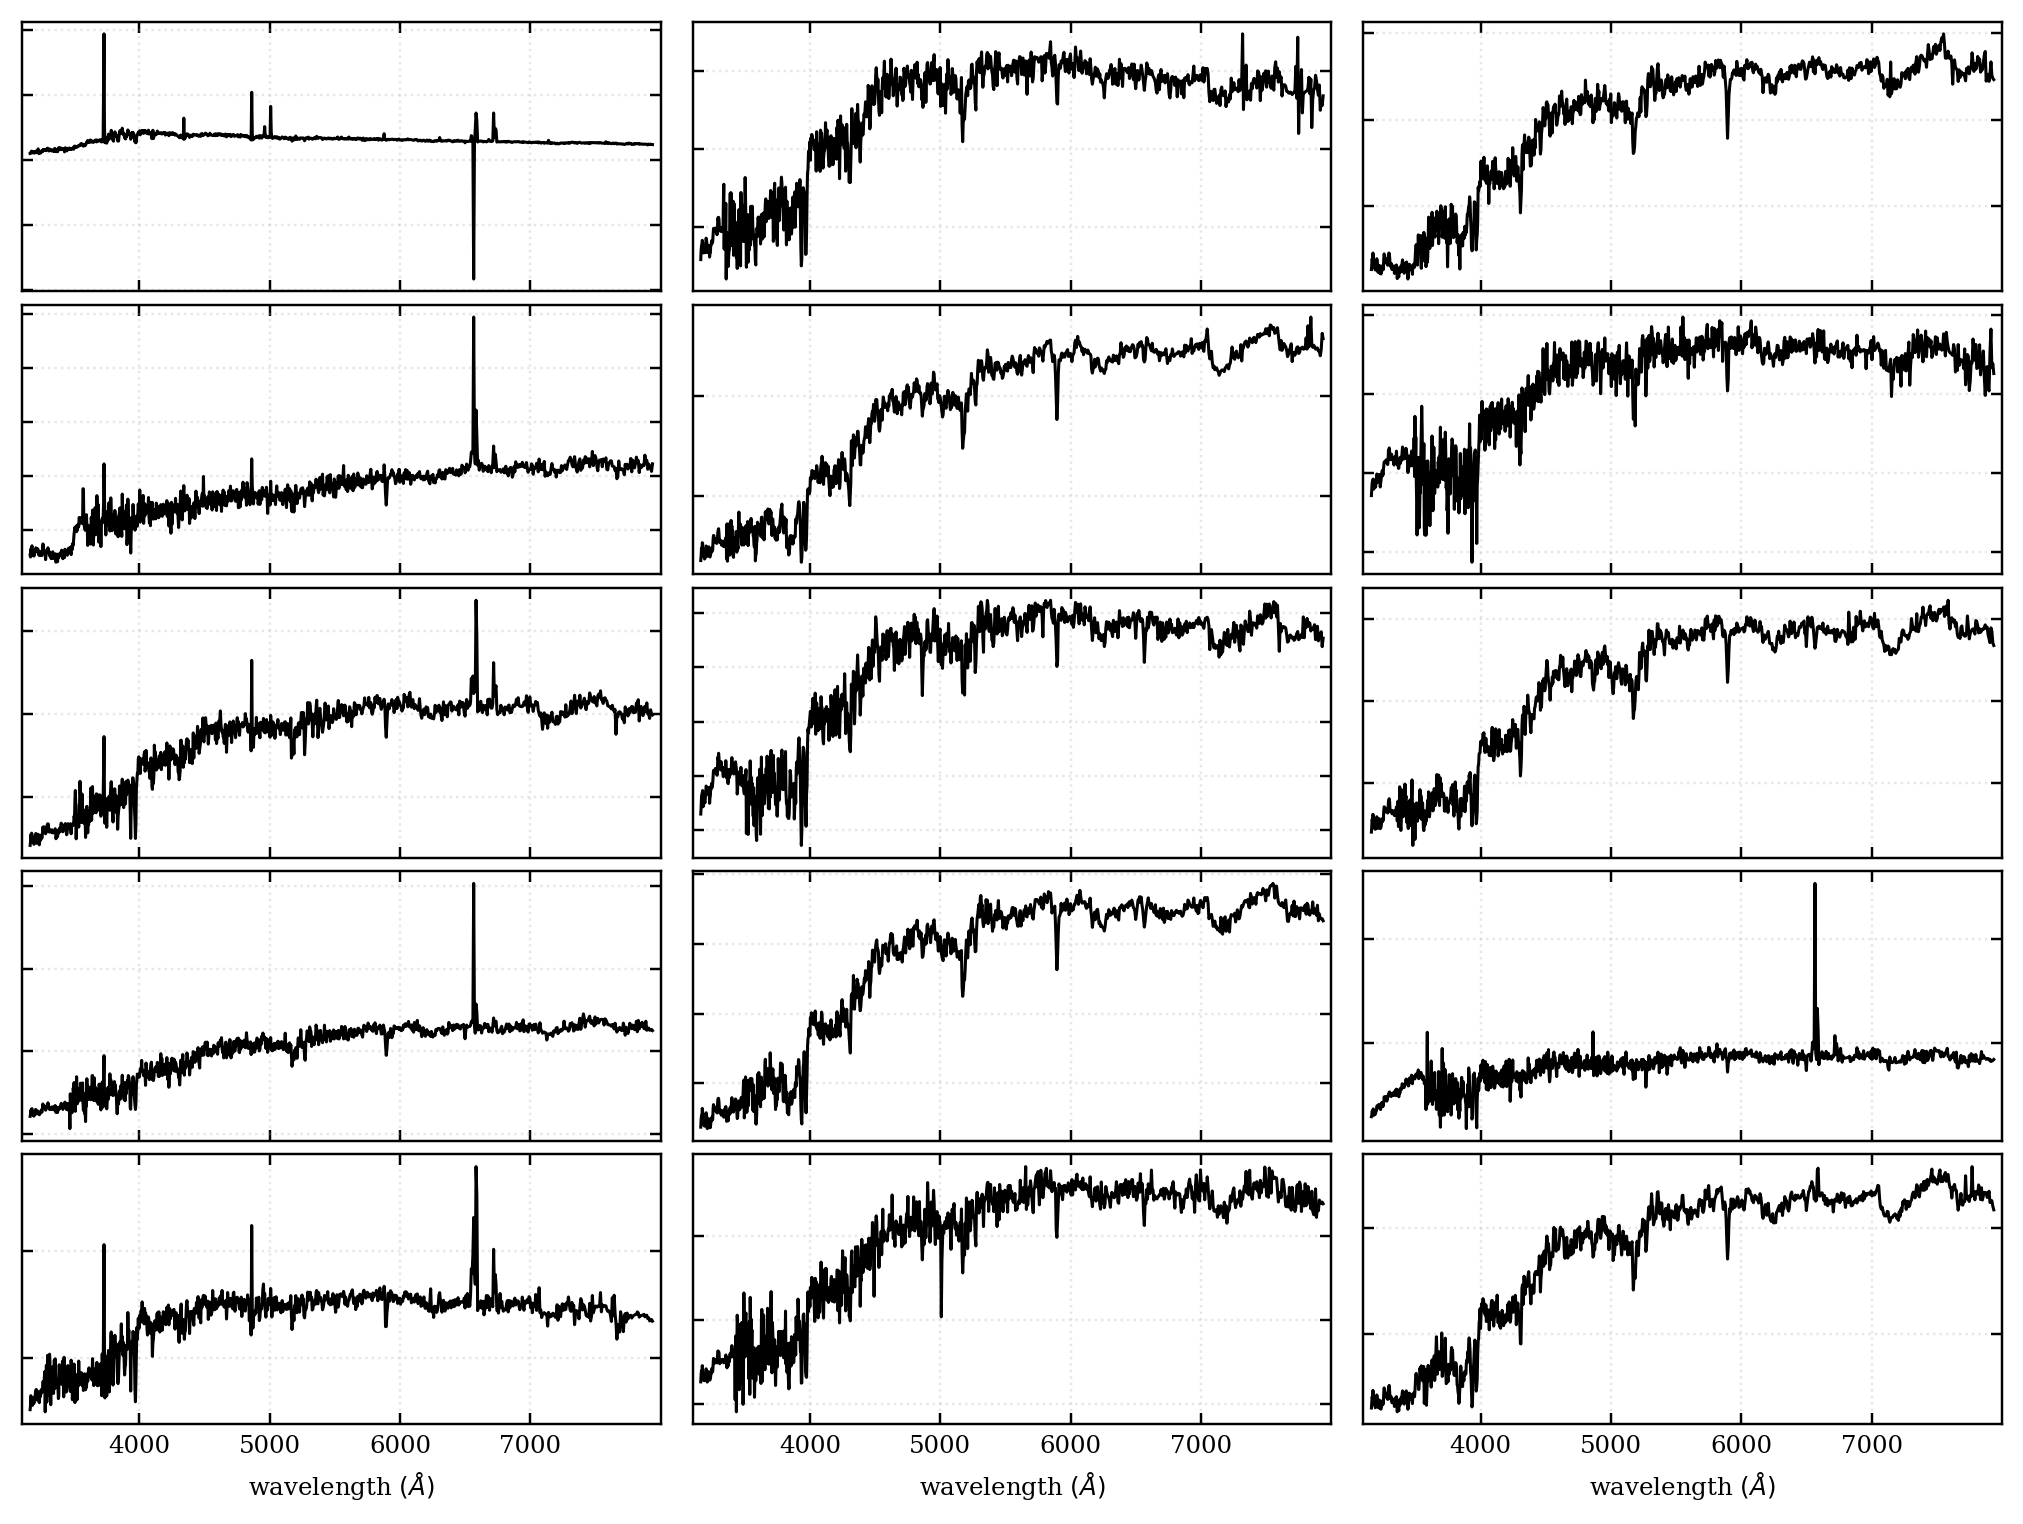

In [2]:
# Author: Jake VanderPlas
# License: BSD
#   The figure produced by this code is published in the textbook
#   "Statistics, Data Mining, and Machine Learning in Astronomy" (2013)
#   For more information, see http://astroML.github.com
#   To report a bug or issue, use the following forum:
#    https://groups.google.com/forum/#!forum/astroml-general
import numpy as np
from matplotlib import pyplot as plt
from astroML.datasets import sdss_corrected_spectra

#----------------------------------------------------------------------
# This function adjusts matplotlib settings for a uniform feel in the textbook.
# Note that with usetex=True, fonts are rendered with LaTeX.  This may
# result in an error if LaTeX is not installed on your system.  In that case,
# you can set usetex to False.
if "setup_text_plots" not in globals():
    from astroML.plotting import setup_text_plots
setup_text_plots(fontsize=8, usetex=False)

#----------------------------------------------------------------------
# Use pre-computed PCA to reconstruct spectra
data = sdss_corrected_spectra.fetch_sdss_corrected_spectra()
spectra = sdss_corrected_spectra.reconstruct_spectra(data)
lam = sdss_corrected_spectra.compute_wavelengths(data)

#------------------------------------------------------------
# select random spectra
np.random.seed(5)
nrows = 5
ncols = 3
ind = np.random.randint(spectra.shape[0], size=nrows * ncols)
spec_sample = spectra[ind]

#----------------------------------------------------------------------
# Plot the results
fig = plt.figure(figsize=(10, 7.5))

fig.subplots_adjust(left=0.05, right=0.95, wspace=0.05,
                    bottom=0.1, top=0.95, hspace=0.05)

for i in range(ncols):
    for j in range(nrows):
        ax = fig.add_subplot(nrows, ncols, ncols * j + 1 + i)
        ax.plot(lam, spec_sample[ncols * j + i], '-k', lw=1)
        ax.set_xlim(3100, 7999)

        ax.yaxis.set_major_formatter(plt.NullFormatter())
        ax.xaxis.set_major_locator(plt.MultipleLocator(1000))
        if j < nrows - 1:
            ax.xaxis.set_major_formatter(plt.NullFormatter())
        else:
            plt.xlabel(r'wavelength $(\AA)$')

        ylim = ax.get_ylim()
        dy = 0.05 * (ylim[1] - ylim[0])
        ax.set_ylim(ylim[0] - dy, ylim[1] + dy)

plt.show()

<a id="2-intuition"></a>
## 2. Geometric Intuition: Direction of Maximal Variance

Figure 7.1 above illustrates a two-dimensional point cloud drawn from a bivariate Gaussian distribution:
$$\mathbf{x} \sim \mathcal{N}(\boldsymbol{\mu}, \mathbf{C}_X)$$

If we wish to reduce the number of features from 2 dimensions down to 1 dimension:
* **Option A (Feature Selection):** Project onto either the $x$-axis or the $y$-axis. This discards all the variance of the dropped axis, and neither axis is aligned with the intrinsic correlation of the data.
* **Option B (Principal Component Rotation):** Rotate the coordinate frame to align with the **principal axis** of the covariance ellipse (shown by the solid black vector). Projecting onto this axis captures the maximum possible variance ($\sigma_1^2$), while the orthogonal axis (dashed vector) carries minimal variance ($\sigma_2^2$).

<div style="border-left: 5px solid #2b9348; padding: 12px 18px; margin: 15px 0; background: rgba(43, 147, 72, 0.1); border-radius: 4px;">
    <h4 style="margin-top: 0;">💡 Duality: Maximizing Variance $\equiv$ Minimizing Reconstruction Error</h4>
    By the Pythagorean theorem, for any data point $\mathbf{x}_i$, its squared distance from the origin is:
    $$\|\mathbf{x}_i\|^2 = \|\hat{\mathbf{x}}_i\|^2 + \|\mathbf{x}_i - \hat{\mathbf{x}}_i\|^2$$
    where $\hat{\mathbf{x}}_i$ is the projection onto the principal axis. Since $\sum \|\mathbf{x}_i\|^2$ is fixed by the dataset, <b>maximizing the variance of the projection</b> ($\sum \|\hat{\mathbf{x}}_i\|^2$) is mathematically identical to <b>minimizing the mean squared reconstruction error</b> ($\sum \|\mathbf{x}_i - \hat{\mathbf{x}}_i\|^2$).
</div>

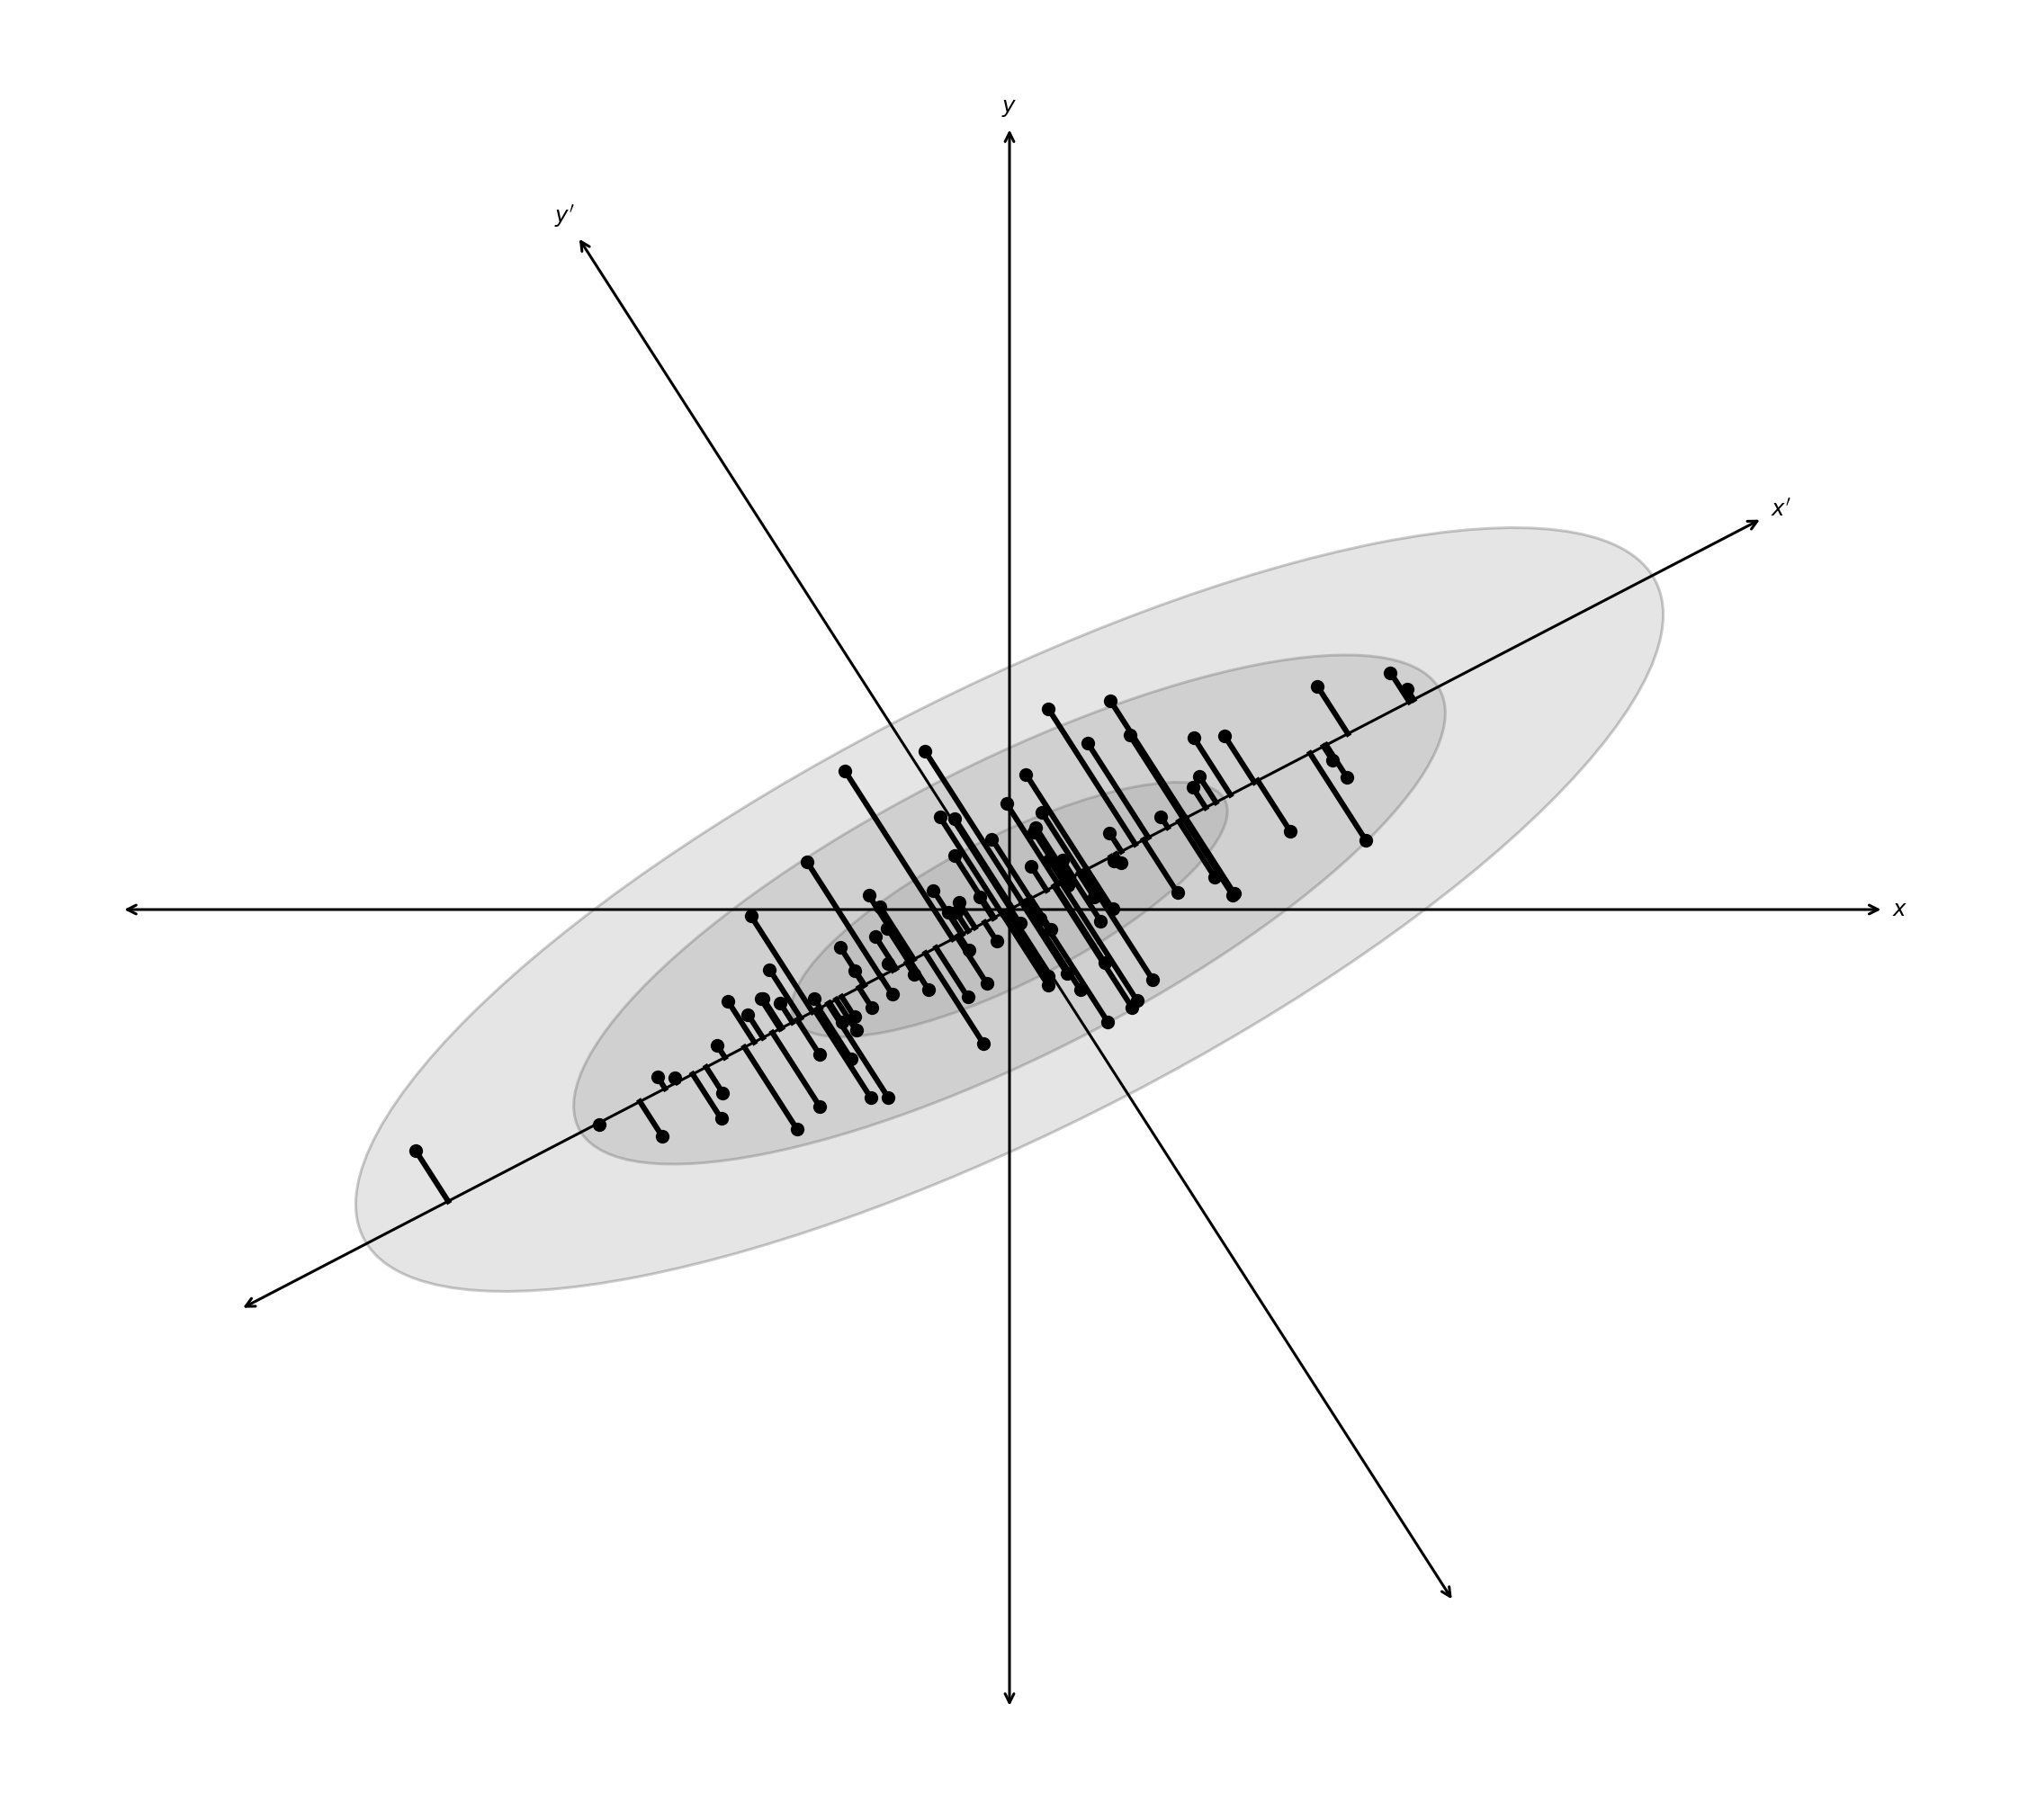

In [3]:
# Author: Jake VanderPlas
# License: BSD
#   The figure produced by this code is published in the textbook
#   "Statistics, Data Mining, and Machine Learning in Astronomy" (2013)
#   For more information, see http://astroML.github.com
#   To report a bug or issue, use the following forum:
#    https://groups.google.com/forum/#!forum/astroml-general
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.patches import Ellipse

#----------------------------------------------------------------------
# This function adjusts matplotlib settings for a uniform feel in the textbook.
# Note that with usetex=True, fonts are rendered with LaTeX.  This may
# result in an error if LaTeX is not installed on your system.  In that case,
# you can set usetex to False.
if "setup_text_plots" not in globals():
    from astroML.plotting import setup_text_plots
setup_text_plots(fontsize=8, usetex=False)

#------------------------------------------------------------
# Set parameters and draw the random sample
np.random.seed(42)
r = 0.9

sigma1 = 0.25
sigma2 = 0.08
rotation = np.pi / 6
s = np.sin(rotation)
c = np.cos(rotation)

X = np.random.normal(0, [sigma1, sigma2], size=(100, 2)).T
R = np.array([[c, -s],
              [s, c]])
X = np.dot(R, X)

#------------------------------------------------------------
# Plot the diagram
fig = plt.figure(figsize=(10, 9), facecolor='w')
ax = plt.axes((0, 0, 1, 1), xticks=[], yticks=[], frameon=False)

# draw axes
ax.annotate(r'$x$', (-r, 0), (r, 0),
            ha='center', va='center',
            arrowprops=dict(arrowstyle='<->', color='k', lw=1))
ax.annotate(r'$y$', (0, -r), (0, r),
            ha='center', va='center',
            arrowprops=dict(arrowstyle='<->', color='k', lw=1))

# draw rotated axes
ax.annotate(r'$x^\prime$', (-r * c, -r * s), (r * c, r * s),
            ha='center', va='center',
            arrowprops=dict(color='k', arrowstyle='<->', lw=1))
ax.annotate(r'$y^\prime$', (r * s, -r * c), (-r * s, r * c),
            ha='center', va='center',
            arrowprops=dict(color='k', arrowstyle='<->', lw=1))

# scatter points
ax.scatter(X[0], X[1], s=25, lw=0, c='k', zorder=2)

# draw lines
vnorm = np.array([s, -c])
for v in (X.T):
    d = np.dot(v, vnorm)
    v1 = v - d * vnorm
    ax.plot([v[0], v1[0]], [v[1], v1[1]], '-k')

# draw ellipses
for sigma in (1, 2, 3):
    ax.add_patch(Ellipse((0, 0), 2 * sigma * sigma1, 2 * sigma * sigma2,
                         angle=rotation * 180. / np.pi,
                         ec='k', fc='gray', alpha=0.2, zorder=1))

ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)

plt.show()

<a id="3-derivation"></a>
## 3. Mathematical Derivation of Principal Component Analysis

Consider a dataset $\{\mathbf{x}_i\}_{i=1}^N$ comprising $N$ observations, with each observation consisting of $K$ measured features (e.g. wavelength bins in a spectrum, or photometric colors).

We initially center the data by subtracting the sample mean vector $\boldsymbol{\mu} = \frac{1}{N}\sum_{i=1}^N \mathbf{x}_i$:
$$\tilde{\mathbf{x}}_i = \mathbf{x}_i - \boldsymbol{\mu}$$
We assemble these centered vectors into an $N \times K$ data matrix $X$, where row $i$ is $\tilde{\mathbf{x}}_i^T$. The **sample covariance matrix** $C_X$ ($K \times K$) is given by:

<div style="border-left: 5px solid #0096c7; padding: 12px 18px; margin: 15px 0; background: rgba(0, 150, 199, 0.1); border-radius: 4px;">
    <h4 style="margin-top: 0;">📐 Sample Covariance Matrix</h4>
    $$\boxed{ C_X = \frac{X^T X}{N - 1} }$$
</div>

Non-zero off-diagonal elements ($C_{X, jk} \neq 0$) indicate linear correlations between feature $j$ and feature $k$.

---

### Derivation via Lagrange Multipliers
We seek a unit projection vector $\mathbf{r}_1 \in \mathbb{R}^K$ (with $\|\mathbf{r}_1\|^2 = \mathbf{r}_1^T \mathbf{r}_1 = 1$) such that the variance of the projected scalar coordinates $y_{i,1} = \tilde{\mathbf{x}}_i^T \mathbf{r}_1$ is maximized. The sample variance of the projected data is:
$$\sigma_{y,1}^2 = \frac{1}{N-1} \sum_{i=1}^N (\tilde{\mathbf{x}}_i^T \mathbf{r}_1)^2 = \mathbf{r}_1^T \left( \frac{X^T X}{N-1} \right) \mathbf{r}_1 = \mathbf{r}_1^T C_X \mathbf{r}_1$$

Formulating the objective with a Lagrange multiplier $\lambda_1$ to enforce the unit-norm constraint:
$$\phi(\mathbf{r}_1, \lambda_1) = \mathbf{r}_1^T C_X \mathbf{r}_1 - \lambda_1 (\mathbf{r}_1^T \mathbf{r}_1 - 1)$$

Taking the gradient with respect to $\mathbf{r}_1$ and setting it to zero:
$$\nabla_{\mathbf{r}_1} \phi = 2 C_X \mathbf{r}_1 - 2 \lambda_1 \mathbf{r}_1 = 0 \implies \boxed{ C_X \mathbf{r}_1 = \lambda_1 \mathbf{r}_1 }$$

<div style="border-left: 5px solid #6c757d; padding: 12px 18px; margin: 15px 0; background: rgba(108, 117, 125, 0.1); border-radius: 4px;">
    <h4 style="margin-top: 0;">🎯 The Eigenvalue Equation</h4>
    The optimal projection vector $\mathbf{r}_1$ is an <b>eigenvector</b> of the covariance matrix $C_X$, and the Lagrange multiplier $\lambda_1$ is its associated <b>eigenvalue</b>!<br>
    Multiplying on the left by $\mathbf{r}_1^T$:
    $$\lambda_1 = \mathbf{r}_1^T C_X \mathbf{r}_1 = \sigma_{y,1}^2$$
    Hence, to maximize the projected variance, $\mathbf{r}_1$ must be the eigenvector associated with the <b>largest eigenvalue</b> $\lambda_1$.
</div>

Subsequent principal directions $\mathbf{r}_2, \mathbf{r}_3, \dots, \mathbf{r}_K$ are found by imposing mutual orthogonality ($\mathbf{r}_j^T \mathbf{r}_k = \delta_{jk}$), leading to the remaining eigenvectors sorted in descending order of their eigenvalues:
$$\lambda_1 \ge \lambda_2 \ge \dots \ge \lambda_K \ge 0$$

Assembling the eigenvectors into an orthogonal matrix $R = [\mathbf{r}_1, \mathbf{r}_2, \dots, \mathbf{r}_K]$ ($K \times K$), the covariance matrix diagonalizes as:
$$\boxed{ C_X = R \Lambda R^T = R C_Y R^T }$$
where $\Lambda = C_Y = \text{diag}(\lambda_1, \lambda_2, \dots, \lambda_K)$ is the diagonal covariance matrix in the principal coordinate system.

<a id="4-svd"></a>
## 4. Efficient Computation: Singular Value Decomposition (SVD) vs. EVD

Directly computing $C_X = \frac{X^T X}{N-1}$ and solving its eigenvalue problem can be numerically unstable and inefficient when $K$ is large. A more direct and numerically robust route is the **Singular Value Decomposition (SVD)** of the scaled centered data matrix.

Let the scaled data matrix be decomposed as:
$$\boxed{ \frac{X}{\sqrt{N-1}} = U \Sigma V^T }$$
where:
* $U$ is an $N \times N$ (or $N \times K$ in thin SVD) orthogonal matrix of **left-singular vectors**.
* $\Sigma$ is a non-negative diagonal matrix of **singular values** $s_1 \ge s_2 \ge \dots \ge s_{\min(N, K)} \ge 0$.
* $V$ is a $K \times K$ orthogonal matrix of **right-singular vectors**.

---

### Connecting SVD to the Covariance Matrix
Substituting the SVD into the definition of $C_X$:
$$C_X = \left(\frac{X}{\sqrt{N-1}}\right)^T \left(\frac{X}{\sqrt{N-1}}\right) = (U \Sigma V^T)^T (U \Sigma V^T) = V \Sigma U^T U \Sigma V^T$$

Since $U^T U = I$:
$$\boxed{ C_X = V \Sigma^2 V^T }$$

Comparing directly with the spectral decomposition $C_X = R \Lambda R^T$, we obtain the fundamental identity:
$$\boxed{ R = V } \quad \text{and} \quad \boxed{ \Lambda = \Sigma^2 \iff \lambda_i = s_i^2 }$$

<div style="border-left: 5px solid #2b9348; padding: 12px 18px; margin: 15px 0; background: rgba(43, 147, 72, 0.1); border-radius: 4px;">
    <h4 style="margin-top: 0;">⚡ Key Computational Equivalence</h4>
    * The <b>right-singular vectors $V$</b> of $X$ are exactly the <b>principal directions (eigenvectors $R$)</b>.
    * The <b>squared singular values $s_i^2$</b> are exactly the <b>eigenvalues (variances $\lambda_i$)</b>.
    * We can perform PCA directly via SVD on $X$ <b>without ever explicitly forming the $K \times K$ matrix $X^T X$</b>!
</div>

---

### The Dual Matrix: Sample Gram Matrix ($M_X$)
Now consider the inner product between observations (rows of $X$), defining the $N \times N$ matrix:
$$M_X = \frac{X X^T}{N - 1} = (U \Sigma V^T)(V \Sigma U^T) = U \Sigma^2 U^T$$

Notice that $U$ contains the eigenvectors of $M_X$, with the **exact same non-zero eigenvalues** $\lambda_i = s_i^2$. Furthermore, via orthogonality:
$$\boxed{ R = V = \frac{1}{\sqrt{N-1}} X^T U \Sigma^{-1} }$$

| Scenario | Dimensions | Recommended Algorithmic Route | Computational Complexity |
| :--- | :--- | :--- | :--- |
| **Many objects, few features** | $N \gg K$ | EVD of Covariance $C_X$ ($K \times K$) | $\mathcal{O}(N K^2 + K^3)$ |
| **Few objects, wide features** (e.g. rare spectra) | $K \gg N$ | EVD of Dual Matrix $M_X$ ($N \times N$) | $\mathcal{O}(K N^2 + N^3)$ |
| **General / High Precision** | Intermediate | Direct SVD of $X$ | Numerically stable, avoids squaring condition number |

In [4]:
# ==============================================================================
# 5. Numerical Verification: SVD vs. EVD vs. Scikit-Learn PCA
# ==============================================================================
import numpy as np
from sklearn.decomposition import PCA

# 1. Generate synthetic dataset: N=100 observations, K=3 features
np.random.seed(42)
X_raw = np.random.normal(loc=[5.0, 10.0, -2.0], scale=[1.0, 3.0, 0.5], size=(100, 3))

# 2. Crucial Step: Mean-centering
X = X_raw - X_raw.mean(axis=0)
N, K = X.shape

# 3. Method A: SVD of the scaled data matrix
U, s, VT = np.linalg.svd(X / np.sqrt(N - 1), full_matrices=False)
lambda_svd = s ** 2
V_svd = VT.T

# 4. Method B: EVD of the sample covariance matrix C_X
C_X = np.dot(X.T, X) / (N - 1)
evals, evecs = np.linalg.eigh(C_X)

# eigh returns ascending order; reverse to descending
lambda_evd = evals[::-1]
V_evd = evecs[:, ::-1]

# 5. Method C: Scikit-Learn PCA
pca = PCA(n_components=3)
pca.fit(X_raw)  # scikit-learn centers automatically
lambda_sklearn = pca.explained_variance_
V_sklearn = pca.components_.T

# Verification Asserts
print("✅ Comparing Eigenvalues (Variances):")
print("  SVD singular values^2 :", np.round(lambda_svd, 5))
print("  EVD covariance evals   :", np.round(lambda_evd, 5))
print("  Scikit-Learn variances :", np.round(lambda_sklearn, 5))
assert np.allclose(lambda_svd, lambda_evd), "SVD and EVD eigenvalues do not match!"
assert np.allclose(lambda_svd, lambda_sklearn), "SVD and Sklearn eigenvalues do not match!"
print("  -> ALL THREE METHODS YIELD IDENTICAL EIGENVALUES! 🎯\n")

# Sign Ambiguity Note:
# An eigenvector v and -v both satisfy C_X v = lambda v.
# Therefore, V_svd and V_evd columns can differ by a factor of -1.
sign_alignment = np.abs(np.sum(V_svd * V_evd, axis=0))
print("Cosine absolute similarity between SVD & EVD principal directions:")
print(" ", sign_alignment)
assert np.allclose(sign_alignment, [1.0, 1.0, 1.0]), "Eigenvector directions do not align!"
print("  -> Principal axes are completely colinear up to standard sign ambiguity.")

✅ Comparing Eigenvalues (Variances):
  SVD singular values^2 : [8.63435 0.68745 0.29586]
  EVD covariance evals   : [8.63435 0.68745 0.29586]
  Scikit-Learn variances : [8.63435 0.68745 0.29586]
  -> ALL THREE METHODS YIELD IDENTICAL EIGENVALUES! 🎯

Cosine absolute similarity between SVD & EVD principal directions:
  [1. 1. 1.]
  -> Principal axes are completely colinear up to standard sign ambiguity.


In [5]:
# ==============================================================================
# Projection: 3 Intrinsic Dimensions Embedded in a 10-Dimensional Space
# ==============================================================================
np.random.seed(42)

# Generate 100 points with 3 true independent physical components
X_intrinsic = np.random.normal(size=(100, 3))

# Random projection matrix from 3D -> 10D
R_proj = np.random.random((3, 10))

# Observed data matrix X is 10-dimensional, but has only 3 intrinsic degrees of freedom!
X_obs = np.dot(X_intrinsic, R_proj) + 0.05 * np.random.normal(size=(100, 10))

# Perform PCA
pca_10d = PCA(n_components=10)
pca_10d.fit(X_obs)

print("Explained variance ratio across all 10 components:")
for idx, ratio in enumerate(pca_10d.explained_variance_ratio_):
    bar = "█" * int(ratio * 50)
    print(f"  PC {idx+1:2d}: {ratio*100:5.2f}% | {bar}")

cum_var = np.cumsum(pca_10d.explained_variance_ratio_)
print(f"\nTotal variance captured by first 3 components: {cum_var[2]*100:.2f}%")

Explained variance ratio across all 10 components:
  PC  1: 83.69% | █████████████████████████████████████████
  PC  2: 10.65% | █████
  PC  3:  5.49% | ██
  PC  4:  0.04% | 
  PC  5:  0.03% | 
  PC  6:  0.03% | 
  PC  7:  0.02% | 
  PC  8:  0.02% | 
  PC  9:  0.02% | 
  PC 10:  0.01% | 

Total variance captured by first 3 components: 99.83%


<a id="6-preprocessing"></a>
## 6. Data Preprocessing & Whitening in Astronomy

Before applying PCA to astronomical data, two critical preprocessing transformations must be carefully evaluated:

### 1. Centering (Mandatory)
$$\tilde{x}_{ik} = x_{ik} - \bar{x}_k$$
PCA identifies directions of variance around the origin. If the data are not centered, the first component will simply point toward the dataset's centroid $\boldsymbol{\mu}$, confounding the overall average brightness with intrinsic morphological or spectral variance.

### 2. Standardization / Whitening (Heterogeneous Observables)
$$\tilde{x}_{ik} = \frac{x_{ik} - \bar{x}_k}{\sigma_k}$$
When features have disparate units (e.g. flux in nanojanskies, angular radius in arcseconds, redshift $z$, velocity dispersion in km/s), unscaled PCA will be overwhelmingly dominated by whichever feature has the numerically largest variance, regardless of physical significance. Whitening ensures each feature contributes unit variance.

<div style="border-left: 5px solid #e09f3e; padding: 12px 18px; margin: 15px 0; background: rgba(224, 159, 62, 0.12); border-radius: 4px;">
    <h4 style="margin-top: 0;">🔭 Astronomical Normalization of Spectra</h4>
    In the case of galaxy spectra, features are homogeneous (flux across wavelength bins $\lambda$). Rather than standardizing each wavelength column, a standard astronomical practice is to <b>normalize each spectrum to unit total flux</b>:
    $$f_{i}(\lambda) \leftarrow \frac{f_i(\lambda)}{\int f_i(\lambda) d\lambda}$$
    This removes trivial distance-dependent and luminosity-dependent scale factors, allowing PCA to focus entirely on <b>spectral shapes, continuum slopes, stellar absorption features, and emission line ratios</b>.
</div>

@pickle_results: computing results and saving to 'spec_decompositions.pkl'


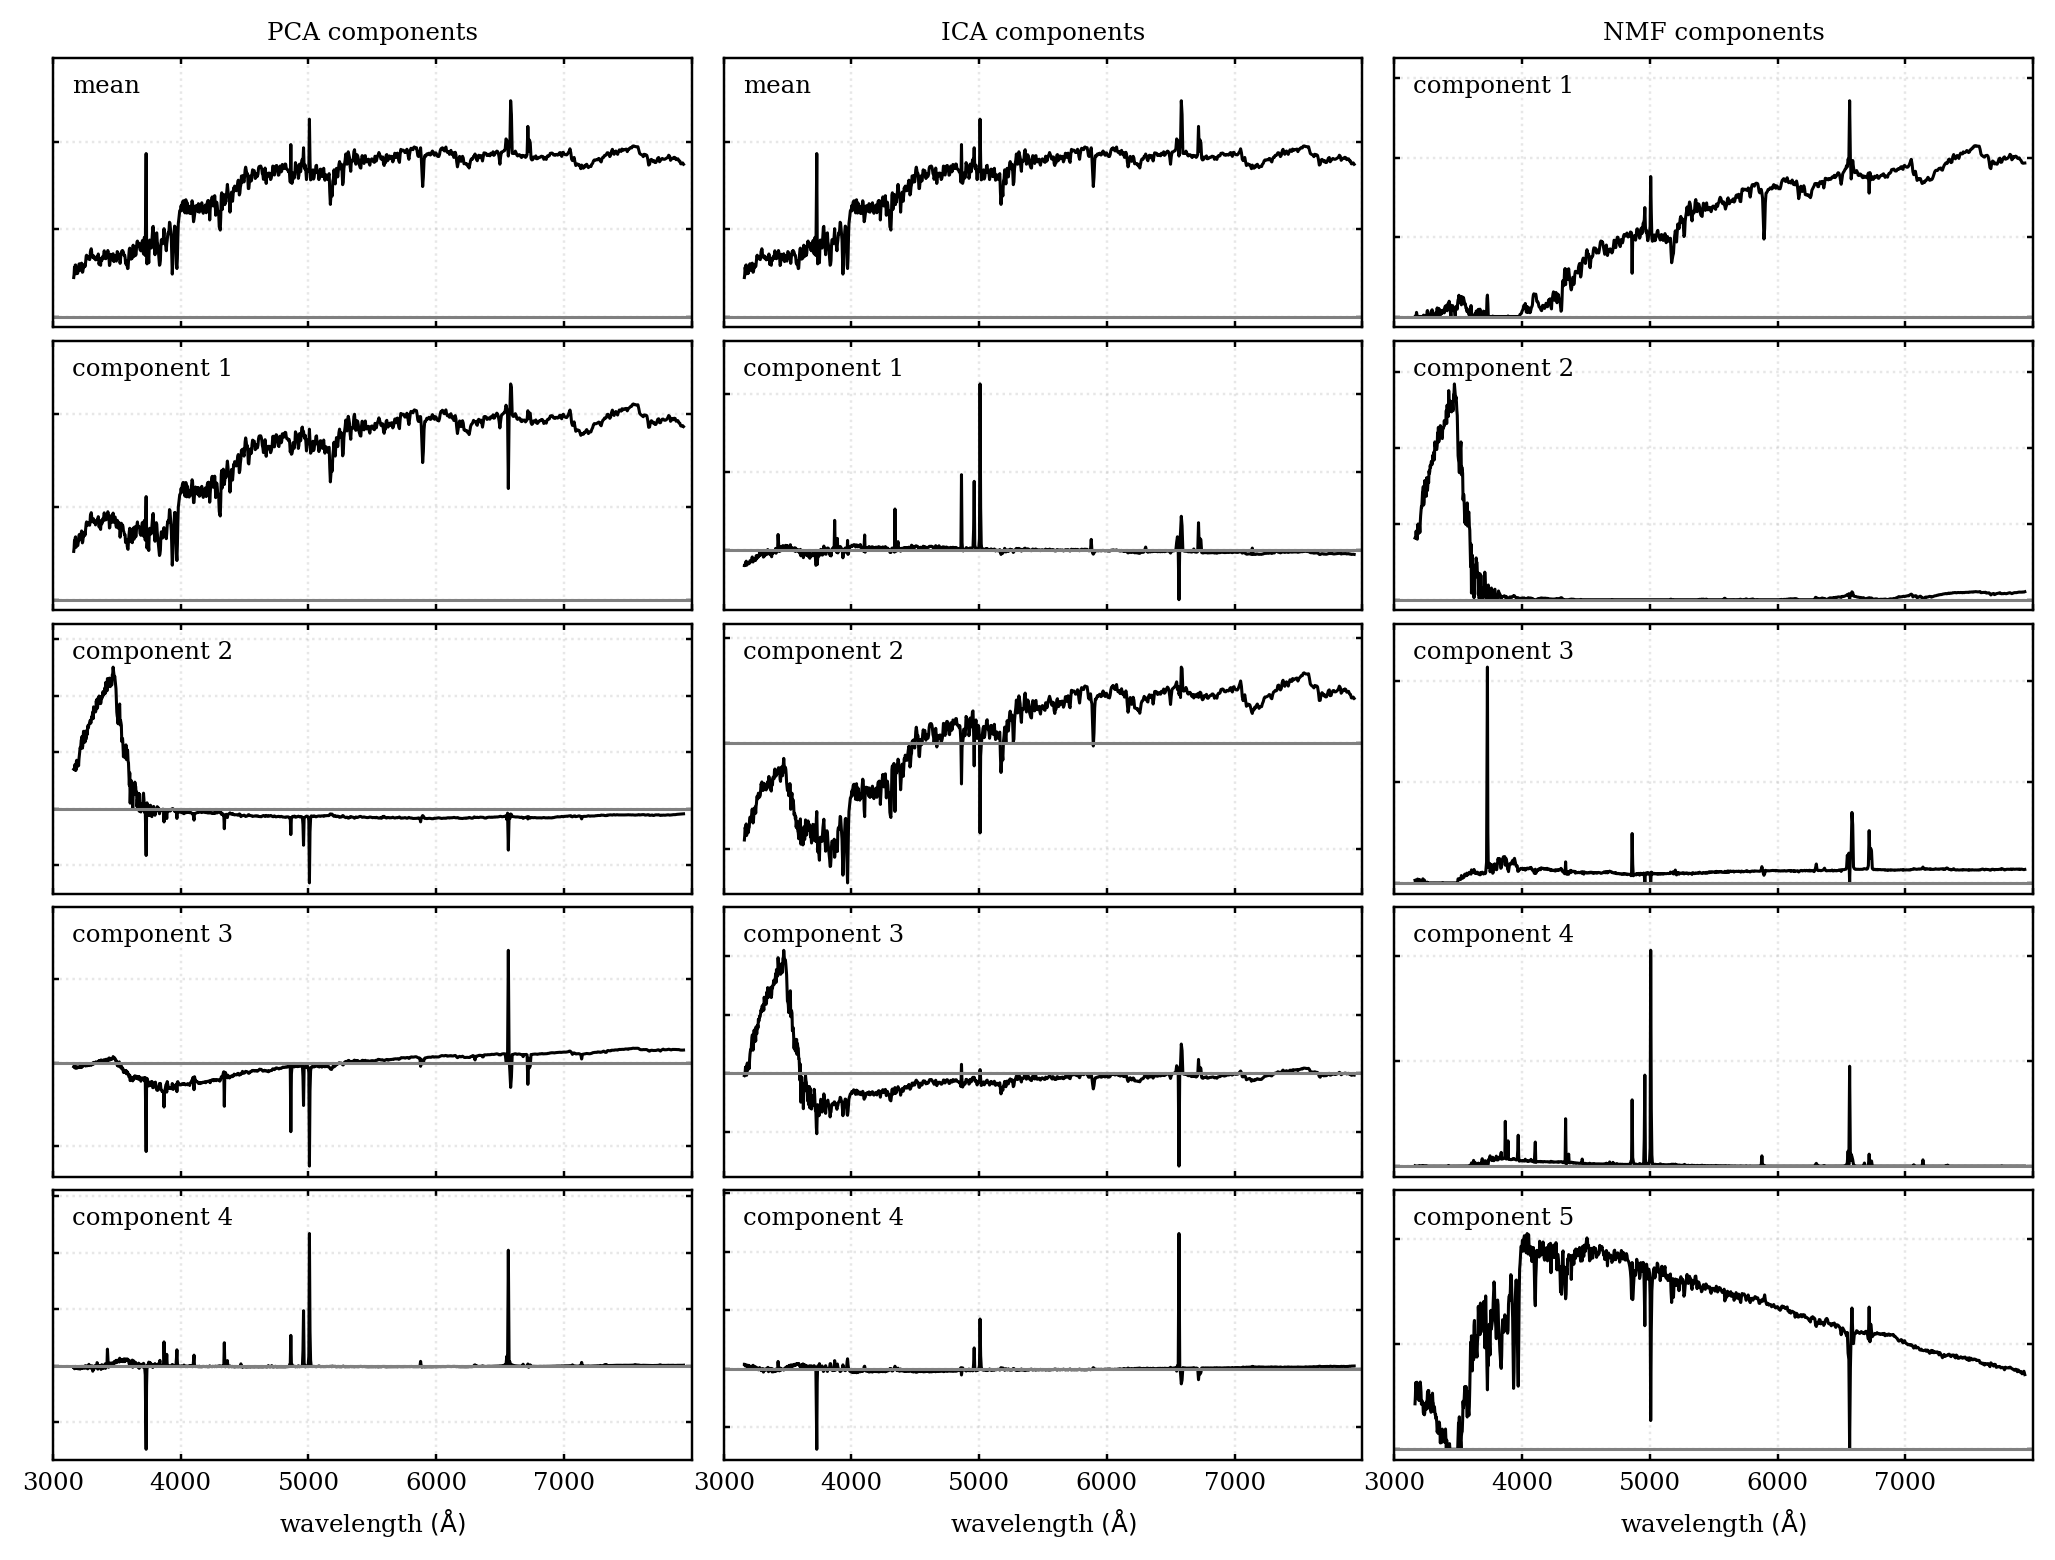

In [6]:
# Author: Jake VanderPlas
# License: BSD
#   The figure produced by this code is published in the textbook
#   "Statistics, Data Mining, and Machine Learning in Astronomy" (2013)
#   For more information, see http://astroML.github.com
#   To report a bug or issue, use the following forum:
#    https://groups.google.com/forum/#!forum/astroml-general
import numpy as np
from matplotlib import pyplot as plt

from sklearn.decomposition import NMF, FastICA, PCA

from astroML.datasets import sdss_corrected_spectra
from astroML.utils.decorators import pickle_results

#----------------------------------------------------------------------
# This function adjusts matplotlib settings for a uniform feel in the textbook.
# Note that with usetex=True, fonts are rendered with LaTeX.  This may
# result in an error if LaTeX is not installed on your system.  In that case,
# you can set usetex to False.
if "setup_text_plots" not in globals():
    from astroML.plotting import setup_text_plots
setup_text_plots(fontsize=8, usetex=False)

#------------------------------------------------------------
# Download data
data = sdss_corrected_spectra.fetch_sdss_corrected_spectra()
spectra = sdss_corrected_spectra.reconstruct_spectra(data)
wavelengths = sdss_corrected_spectra.compute_wavelengths(data)


#----------------------------------------------------------------------
# Compute PCA, ICA, and NMF components
#  we'll save the results so that they can be re-used
@pickle_results('spec_decompositions.pkl')
def compute_PCA_ICA_NMF(n_components=5):
    spec_mean = spectra.mean(0)

    # PCA: use randomized PCA for speed
    pca = PCA(n_components - 1, random_state=0, svd_solver='randomized')
    pca.fit(spectra)
    pca_comp = np.vstack([spec_mean,
                          pca.components_])

    # ICA treats sequential observations as related.  Because of this, we need
    # to fit with the transpose of the spectra
    ica = FastICA(n_components - 1, random_state=0)
    ica.fit(spectra.T)
    ica_comp = np.vstack([spec_mean,
                          ica.transform(spectra.T).T])

    # NMF requires all elements of the input to be greater than zero
    spectra[spectra < 0] = 0
    nmf = NMF(n_components, random_state=0)
    nmf.fit(spectra)
    nmf_comp = nmf.components_

    return pca_comp, ica_comp, nmf_comp

n_components = 5
decompositions = compute_PCA_ICA_NMF(n_components)

#----------------------------------------------------------------------
# Plot the results
fig = plt.figure(figsize=(10, 7.5))
fig.subplots_adjust(left=0.05, right=0.95, wspace=0.05,
                    bottom=0.1, top=0.95, hspace=0.05)

titles = ['PCA components', 'ICA components', 'NMF components']

for i, comp in enumerate(decompositions):
    for j in range(n_components):
        ax = fig.add_subplot(n_components, 3, 3 * j + 1 + i)

        ax.yaxis.set_major_formatter(plt.NullFormatter())
        ax.xaxis.set_major_locator(plt.MultipleLocator(1000))
        if j < n_components - 1:
            ax.xaxis.set_major_formatter(plt.NullFormatter())
        else:
            ax.xaxis.set_major_locator(
                plt.FixedLocator(list(range(3000, 7999, 1000))))
            ax.set_xlabel(r'wavelength ${\rm (\AA)}$')

        ax.plot(wavelengths, comp[j], '-k', lw=1)

        # plot zero line
        xlim = [3000, 8000]
        ax.plot(xlim, [0, 0], '-', c='gray', lw=1)

        if j == 0:
            ax.set_title(titles[i])

        if titles[i].startswith('PCA') or titles[i].startswith('ICA'):
            if j == 0:
                label = 'mean'
            else:
                label = 'component %i' % j
        else:
            label = 'component %i' % (j + 1)

        ax.text(0.03, 0.94, label, transform=ax.transAxes,
                ha='left', va='top')

        for l in ax.get_xticklines() + ax.get_yticklines():
            l.set_markersize(2)

        # adjust y limits
        ylim = plt.ylim()
        dy = 0.05 * (ylim[1] - ylim[0])

        ax.set_ylim(ylim[0] - dy, ylim[1] + 4 * dy)
        ax.set_xlim(xlim)


plt.show()



<a id="8-scree"></a>
## 8. Scree Plots, Eigenvalues & Information Compression

The plot of eigenvalues $\lambda_i$ versus component index $i$ is known as a **Scree Plot** (originating from geological scree—the rubble at the base of a cliff).

<div style="border-left: 5px solid #0096c7; padding: 12px 18px; margin: 15px 0; background: rgba(0, 150, 199, 0.1); border-radius: 4px;">
    <h4 style="margin-top: 0;">📐 Cumulative Explained Variance Ratio</h4>
    The fraction of total dataset variance retained by the first $r$ principal components is given by:
    $$\boxed{ \alpha(r) = \frac{\sum_{i=1}^{r} \lambda_i}{\sum_{i=1}^{K} \lambda_i} = \frac{\sum_{i=1}^{r} s_i^2}{\sum_{i=1}^{K} s_i^2} }$$
</div>

In our SDSS galaxy sample, each spectrum has $K = 1,000$ wavelength bins. As shown in the figure below:
* The first **10 eigenspectra** account for **$94.3\%$** of the total variance across all 4,000 galaxies!
* Compressing from $1,000$ bins down to $10$ expansion coefficients represents a **$100\times$ data compression factor** with minimal loss of physical information.

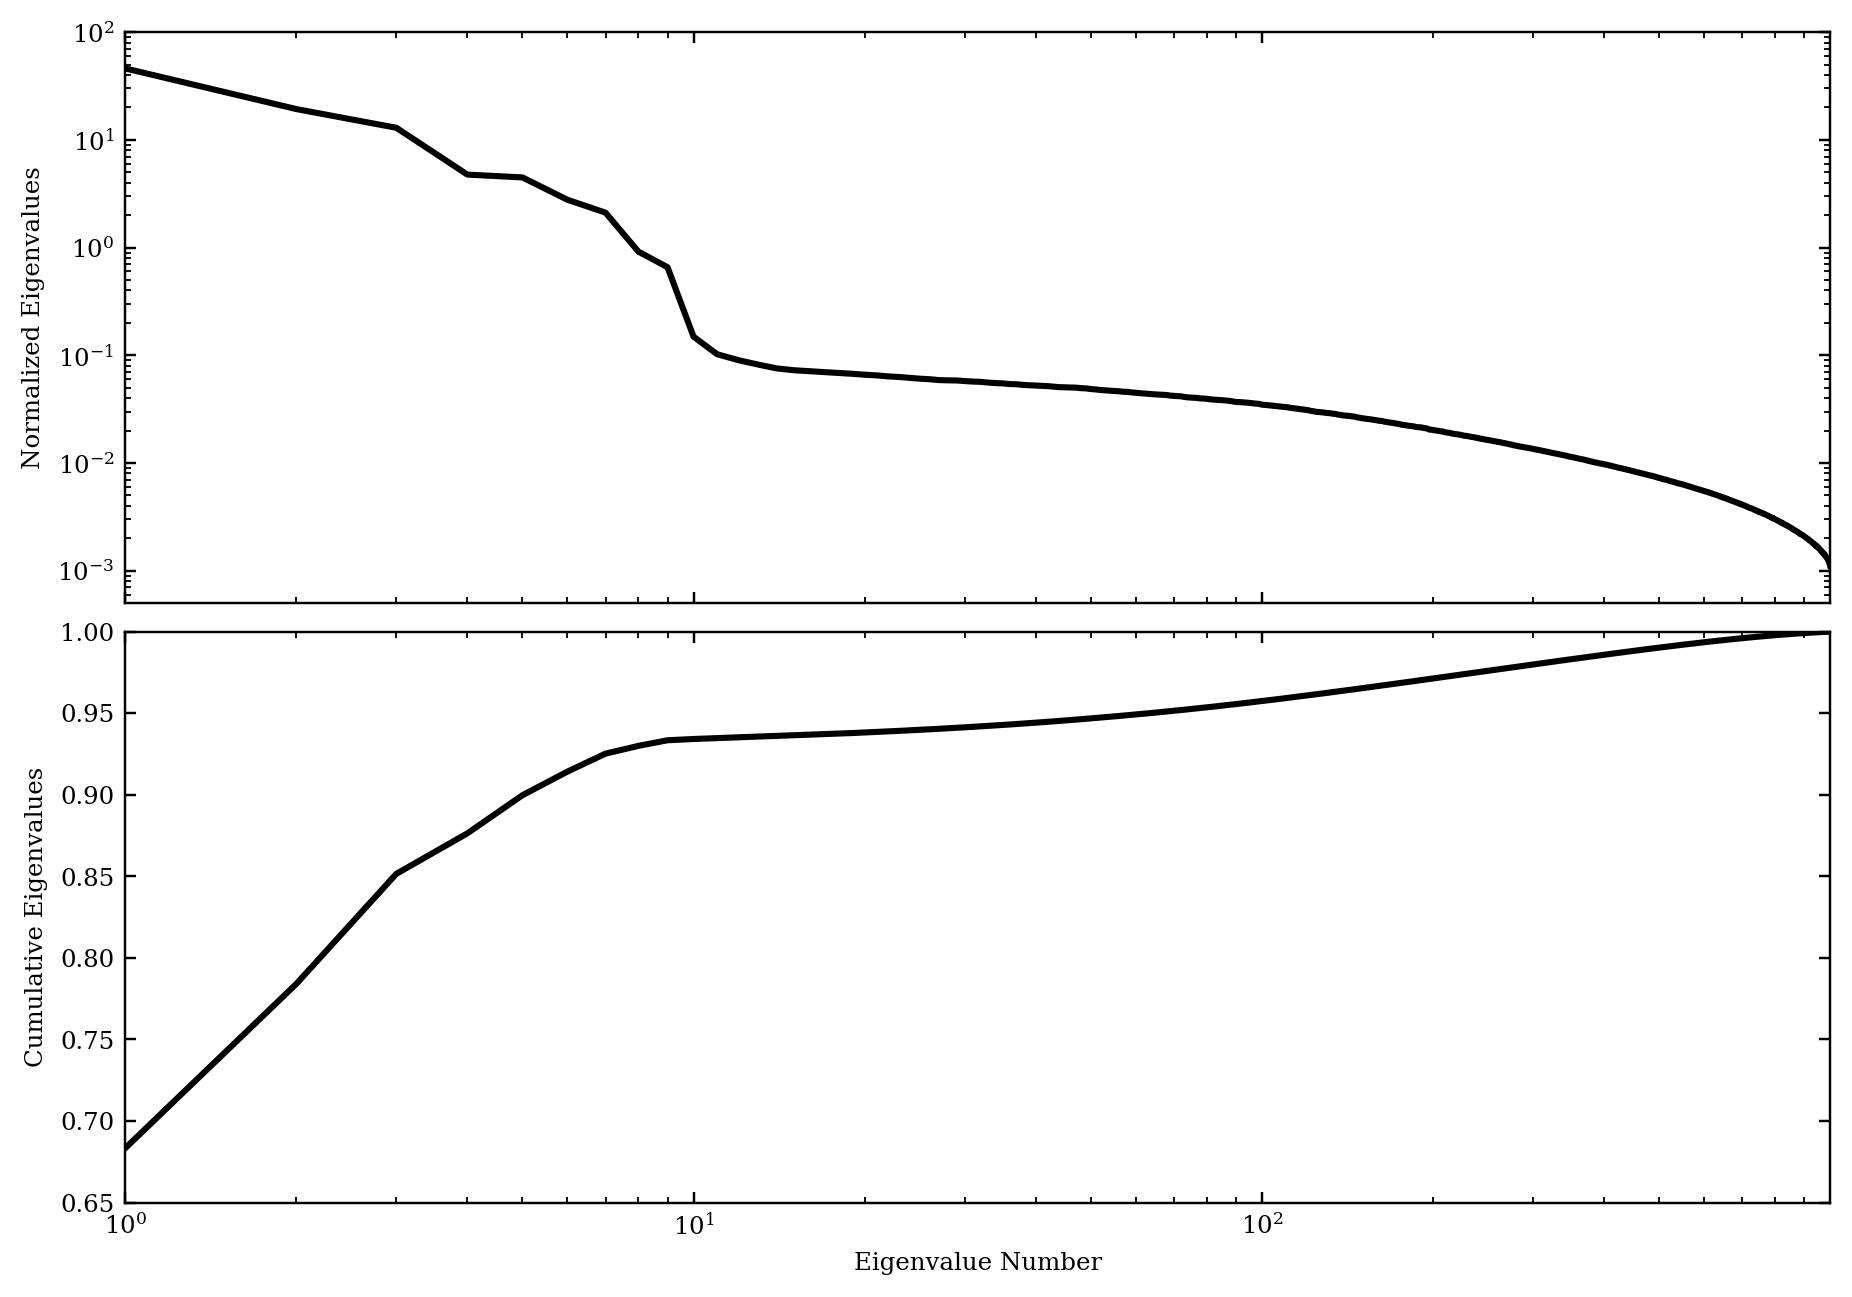

In [7]:
# Author: Jake VanderPlas
# License: BSD
#   The figure produced by this code is published in the textbook
#   "Statistics, Data Mining, and Machine Learning in Astronomy" (2013)
#   For more information, see http://astroML.github.com
#   To report a bug or issue, use the following forum:
#    https://groups.google.com/forum/#!forum/astroml-general
import numpy as np
from matplotlib import pyplot as plt
from astroML import datasets

#----------------------------------------------------------------------
# This function adjusts matplotlib settings for a uniform feel in the textbook.
# Note that with usetex=True, fonts are rendered with LaTeX.  This may
# result in an error if LaTeX is not installed on your system.  In that case,
# you can set usetex to False.
if "setup_text_plots" not in globals():
    from astroML.plotting import setup_text_plots
setup_text_plots(fontsize=8, usetex=False)

#------------------------------------------------------------
# load data:
data = datasets.fetch_sdss_corrected_spectra()
spectra = datasets.sdss_corrected_spectra.reconstruct_spectra(data)

# Eigenvalues can be computed using PCA as in the commented code below:

#from sklearn.decomposition import PCA
#pca = PCA()
#pca.fit(spectra)
#evals = pca.explained_variance_ratio_
#evals_cs = evals.cumsum()

#  because the spectra have been reconstructed from masked values, this
#  is not exactly correct in this case: we'll use the values computed
#  in the file compute_sdss_pca.py
evals = data['evals'] ** 2
evals_cs = evals.cumsum()
evals_cs /= evals_cs[-1]

#------------------------------------------------------------
# plot the eigenvalues
fig = plt.figure(figsize=(10, 7))
fig.subplots_adjust(hspace=0.05, bottom=0.12)

ax = fig.add_subplot(211, xscale='log', yscale='log')
ax.grid()
ax.plot(evals, c='k')
ax.set_ylabel('Normalized Eigenvalues')
ax.xaxis.set_major_formatter(plt.NullFormatter())
ax.set_ylim(5E-4, 100)

ax = fig.add_subplot(212, xscale='log')
ax.grid()
ax.semilogx(evals_cs, color='k')
ax.set_xlabel('Eigenvalue Number')
ax.set_ylabel('Cumulative Eigenvalues')
ax.set_ylim(0.65, 1.00)

plt.show()

<a id="9-physics"></a>
## 9. Physical Interpretation of Eigenspectra (Continuum vs. Emission Lines)

The mathematical components generated by PCA are not arbitrary vectors; in astronomy, they correspond directly to underlying physical processes:

<div style="border-left: 5px solid #2b9348; padding: 12px 18px; margin: 15px 0; background: rgba(43, 147, 72, 0.1); border-radius: 4px;">
    <h4 style="margin-top: 0;">🔬 Astronomical Diagnostics Encoded in Eigenspectra</h4>
    <ul>
        <li><b>Mean Spectrum $\boldsymbol{\mu}(\lambda)$ (Top Row of Figure 7.3):</b> Represents the typical composite stellar population of low-redshift galaxies, showing the 4000 &#197; break and prominent Balmer absorption lines.</li>
        <li><b>First Eigenspectrum ($\mathbf{e}_1$):</b> Governs the broad <b>continuum color slope</b> (red old passive stellar population vs. blue young starburst population). It controls the fundamental dichotomy between elliptical and spiral galaxies.</li>
        <li><b>Second Eigenspectrum ($\mathbf{e}_2$):</b> Strongly modulates the <b>4000 &#197; break</b> strength and the balance of star-formation age indicators.</li>
        <li><b>Third & Fourth Eigenspectra ($\mathbf{e}_3, \mathbf{e}_4$):</b> Characterized by sharp, localized <b>nebular emission lines</b> ([O II] $\lambda 3727$, [O III] $\lambda 4959, 5007$, H$\beta$, H$\alpha$). These components capture ionization from active star-forming regions and Active Galactic Nuclei (AGN).</li>
    </ul>
</div>

### Limitations of Linear PCA in Astronomy:
1. **Non-linear Variations (Quasar Broad Lines):** While quiescent galaxy spectra are well-reconstructed with $\sim 10$ components, broad-line active galaxies and quasars involve kinematics (virial motion of broad-line clouds) that vary non-linearly with inclination and black hole mass. Accurately modeling quasar line profiles can require $>30$ components.
2. **Rare Transients:** Because PCA maximizes *sample-wide variance*, rare physical features (such as unusual absorption systems or supernova signatures) will have negligible variance and will be relegated to high-order components or lost in truncation.

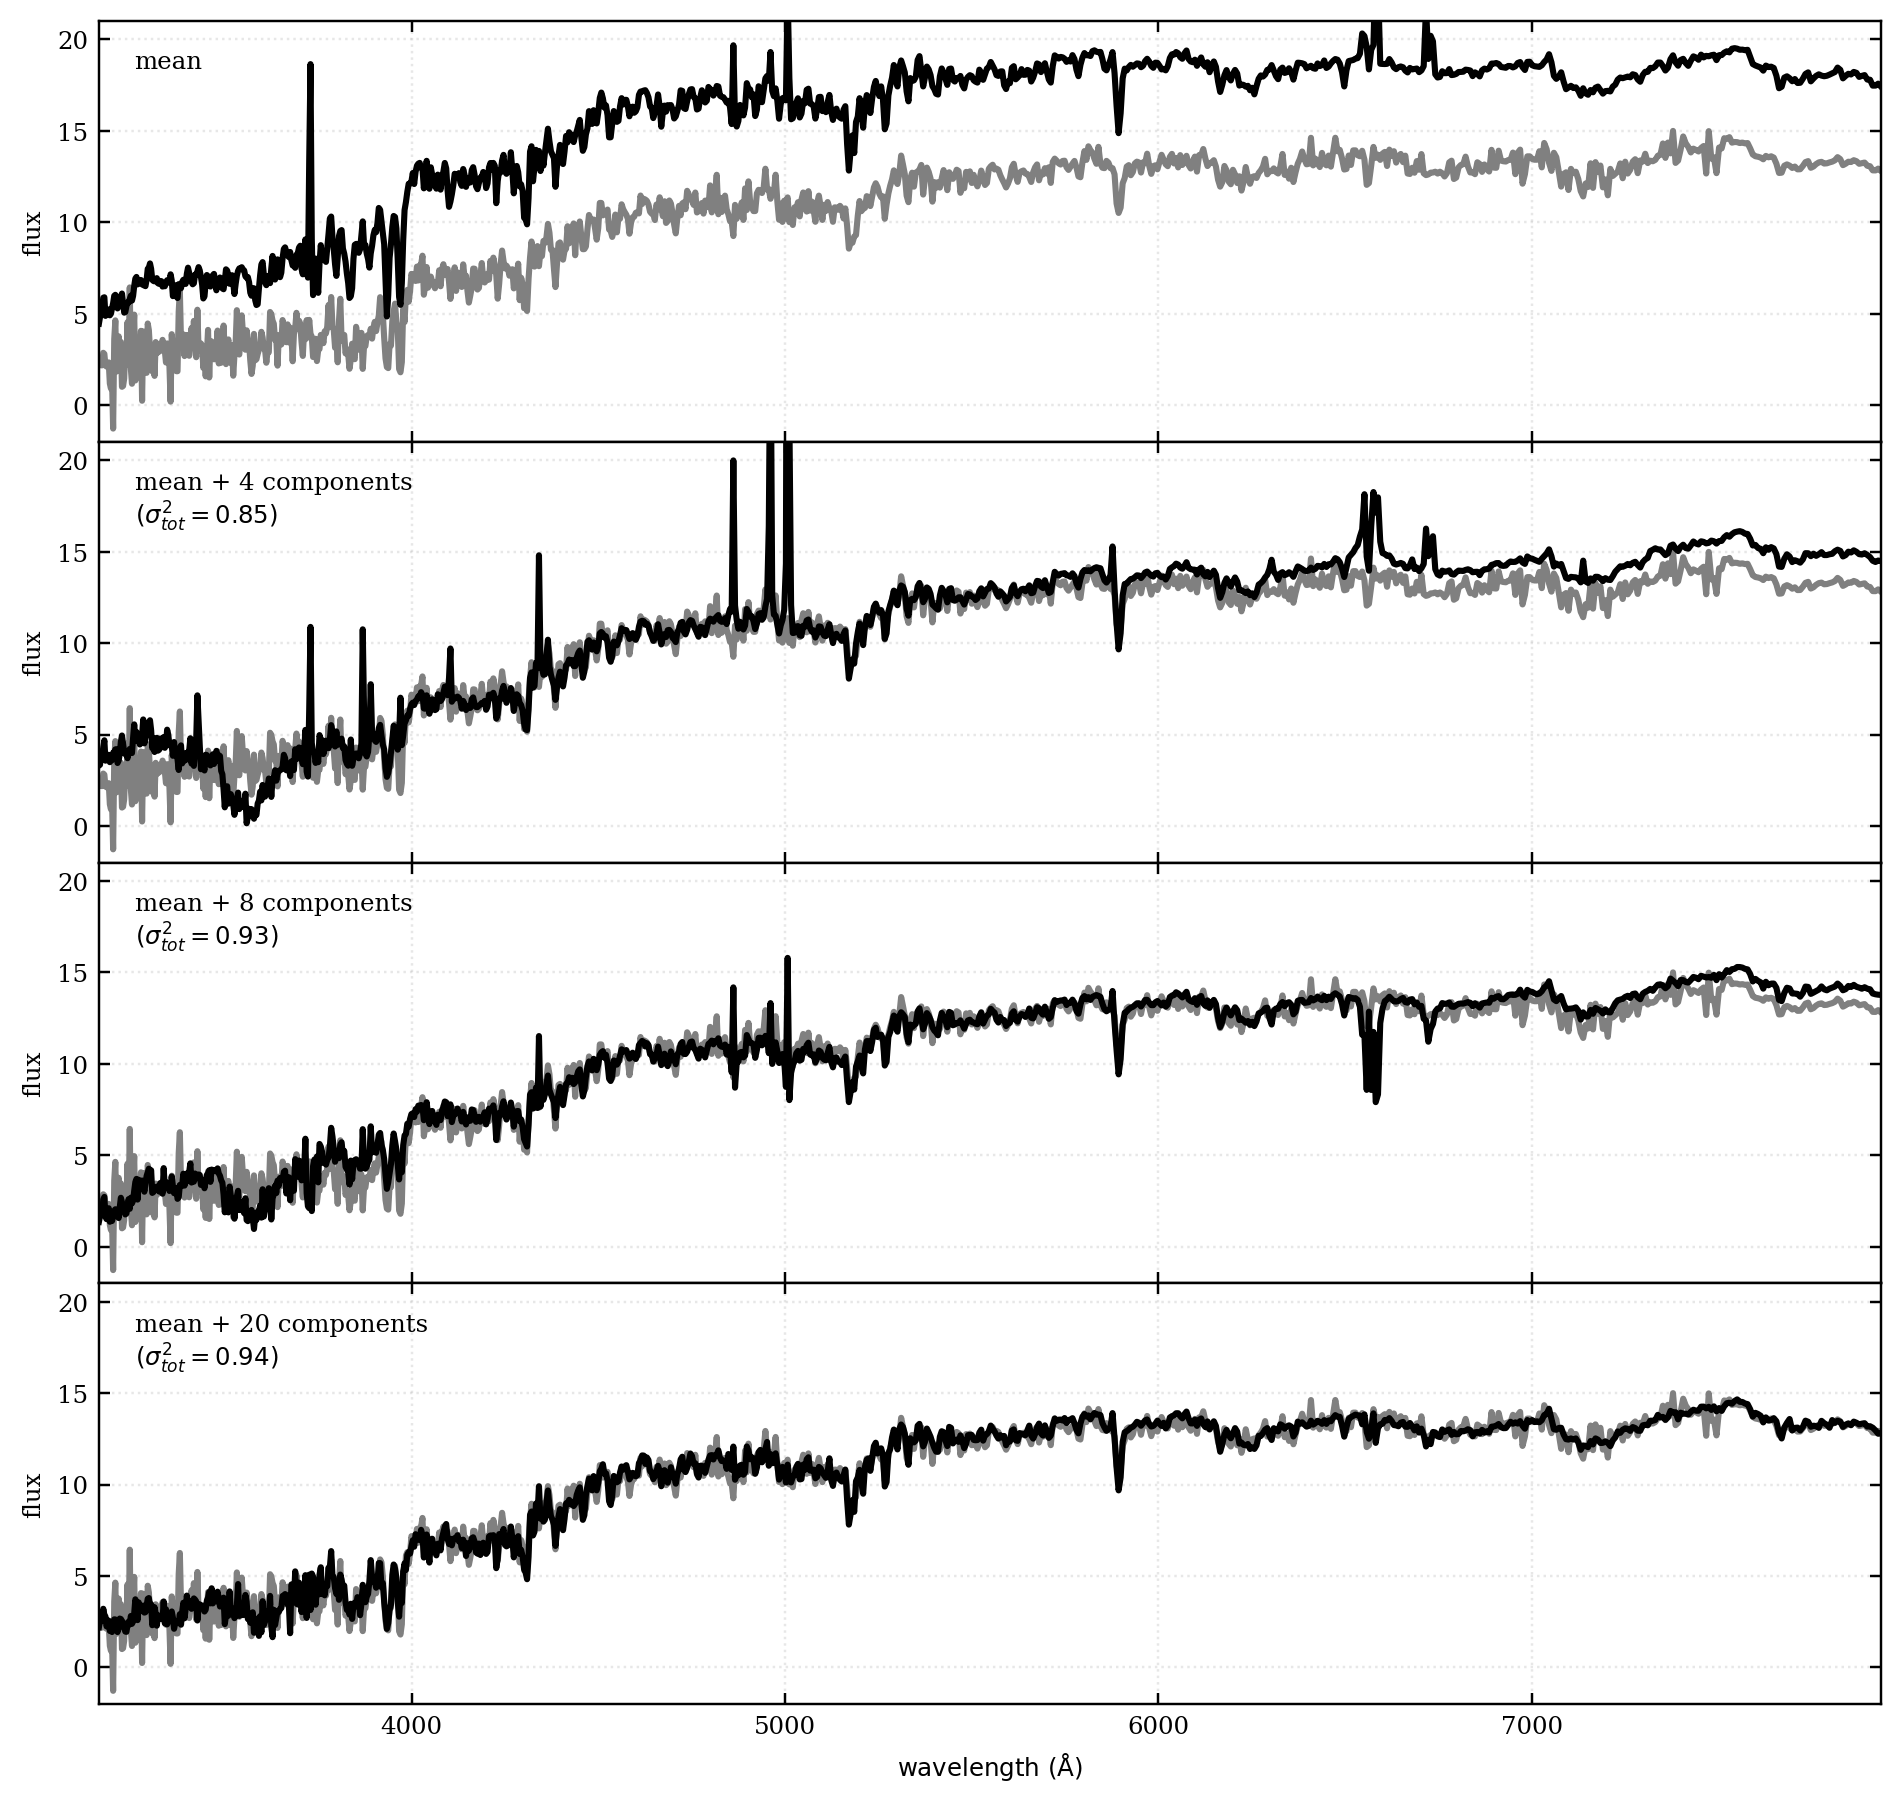

In [8]:
# Author: Jake VanderPlas
# License: BSD
#   The figure produced by this code is published in the textbook
#   "Statistics, Data Mining, and Machine Learning in Astronomy" (2013)
#   For more information, see http://astroML.github.com
#   To report a bug or issue, use the following forum:
#    https://groups.google.com/forum/#!forum/astroml-general
import numpy as np
from matplotlib import pyplot as plt

from sklearn.decomposition import PCA

from astroML.datasets import sdss_corrected_spectra
from astroML.utils.decorators import pickle_results

#----------------------------------------------------------------------
# This function adjusts matplotlib settings for a uniform feel in the textbook.
# Note that with usetex=True, fonts are rendered with LaTeX.  This may
# result in an error if LaTeX is not installed on your system.  In that case,
# you can set usetex to False.
if "setup_text_plots" not in globals():
    from astroML.plotting import setup_text_plots
setup_text_plots(fontsize=8, usetex=False)


#------------------------------------------------------------
# Download data
data = sdss_corrected_spectra.fetch_sdss_corrected_spectra()
spectra = sdss_corrected_spectra.reconstruct_spectra(data)
wavelengths = sdss_corrected_spectra.compute_wavelengths(data)

#------------------------------------------------------------
# Compute PCA components

# Eigenvalues can be computed using PCA as in the commented code below:

#from sklearn.decomposition import PCA
#pca = PCA()
#pca.fit(spectra)
#evals = pca.explained_variance_ratio_
#evals_cs = evals.cumsum()

#  because the spectra have been reconstructed from masked values, this
#  is not exactly correct in this case: we'll use the values computed
#  in the file compute_sdss_pca.py
evals = data['evals'] ** 2
evals_cs = evals.cumsum()
evals_cs /= evals_cs[-1]
evecs = data['evecs']
spec_mean = spectra.mean(0)

#------------------------------------------------------------
# Find the coefficients of a particular spectrum
spec = spectra[1]
coeff = np.dot(evecs, spec - spec_mean)

#------------------------------------------------------------
# Plot the sequence of reconstructions
fig = plt.figure(figsize=(10, 9))
fig.subplots_adjust(hspace=0, top=0.95, bottom=0.1, left=0.12, right=0.93)

for i, n in enumerate([0, 4, 8, 20]):
    ax = fig.add_subplot(411 + i)
    ax.plot(wavelengths, spec, '-', c='gray')
    ax.plot(wavelengths, spec_mean + np.dot(coeff[:n], evecs[:n]), '-k')

    if i < 3:
        ax.xaxis.set_major_formatter(plt.NullFormatter())

    ax.set_ylim(-2, 21)
    ax.set_ylabel('flux')

    if n == 0:
        text = "mean"
    elif n == 1:
        text = "mean + 1 component\n"
        text += r"$(\sigma^2_{tot} = %.2f)$" % evals_cs[n - 1]
    else:
        text = "mean + %i components\n" % n
        text += r"$(\sigma^2_{tot} = %.2f)$" % evals_cs[n - 1]

    ax.text(0.02, 0.93, text, ha='left', va='top', transform=ax.transAxes)

fig.axes[-1].set_xlabel(r'${\rm wavelength\ (\AA)}$')
plt.show()

<a id="10-truncation"></a>
## 10. Choosing the Level of Truncation in an Expansion

When reconstructing spectra from a truncated sum $\hat{\mathbf{x}} = \boldsymbol{\mu} + \sum_{i=1}^r \theta_i \mathbf{e}_i$:
* **Too many components ($r$ too large):** Re-injects observational photon noise and sky residuals into the model.
* **Too few components ($r$ too small):** Blurs localized emission lines and underfits subtle astrophysical features.

### Truncation Criteria:
1. **Variance Threshold:** Keep $r$ components such that $\alpha(r) \ge 0.85\text{--}0.95$.
2. **Knee / Elbow Criterion (Cattell Scree Test):** Identify the sharp change in the derivative of the eigenvalue curve where variance plateaus to the noise floor.
3. **Kaiser Criterion:** For standardized variables, discard components with eigenvalues $\lambda_i < 1$ (which carry less variance than a single raw variable).

---

<a id="11-gappy"></a>
## 11. PCA with Missing & Censored Data (Gappy PCA)

In real astronomical observations, data are inevitably corrupted by detector bad pixels, cosmic ray strikes, telluric absorption bands, or incomplete spectral coverage. Standard PCA cannot be evaluated when matrix elements are missing.

Following **Connolly & Szalay (1999)**, we define for an observed spectrum $\mathbf{x}^o$ a wavelength-dependent weight vector $w(k)$:
$$w(k) = \begin{cases} \frac{1}{\sigma^2(k)} & \text{if pixel } k \text{ is valid} \\ 0 & \text{if pixel } k \text{ is masked / missing} \end{cases}$$

We solve for expansion coefficients $\boldsymbol{\theta}$ that minimize the weighted quadratic loss:
$$\chi^2 = \sum_{k=1}^K w(k) \left( x^o(k) - \sum_{i=1}^r \theta_i e_i(k) \right)^2$$

Setting $\frac{\partial \chi^2}{\partial \theta_j} = 0$ yields the linear system:
$$\boxed{ \sum_{i=1}^r M_{ji} \theta_i = F_j \implies \boldsymbol{\theta} = M^{-1} \mathbf{F} }$$

where:
* **Coupling Matrix $M$ ($r \times r$):** $M_{ji} = \sum_{k=1}^K w(k) e_j(k) e_i(k)$ (measures the loss of orthogonality over the unmasked pixels).
* **Weighted Data Projection $\mathbf{F}$ ($r \times 1$):** $F_j = \sum_{k=1}^K w(k) x^o(k) e_j(k)$.

The parameter covariance matrix is given analytically by:
$$\boxed{ \text{Cov}(\theta_i, \theta_j) = (M^{-1})_{ij} }$$

As long as the number of unmasked pixels exceeds the truncation order ($N_{\text{unmasked}} > r$), PCA can accurately interpolate across gaps and reconstruct missing spectral lines using the learned global correlations!

<>:84: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:84: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
/tmp/ipykernel_3977072/1017766814.py:84: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  ax.set_xlabel('$\lambda\ (\AA)$')


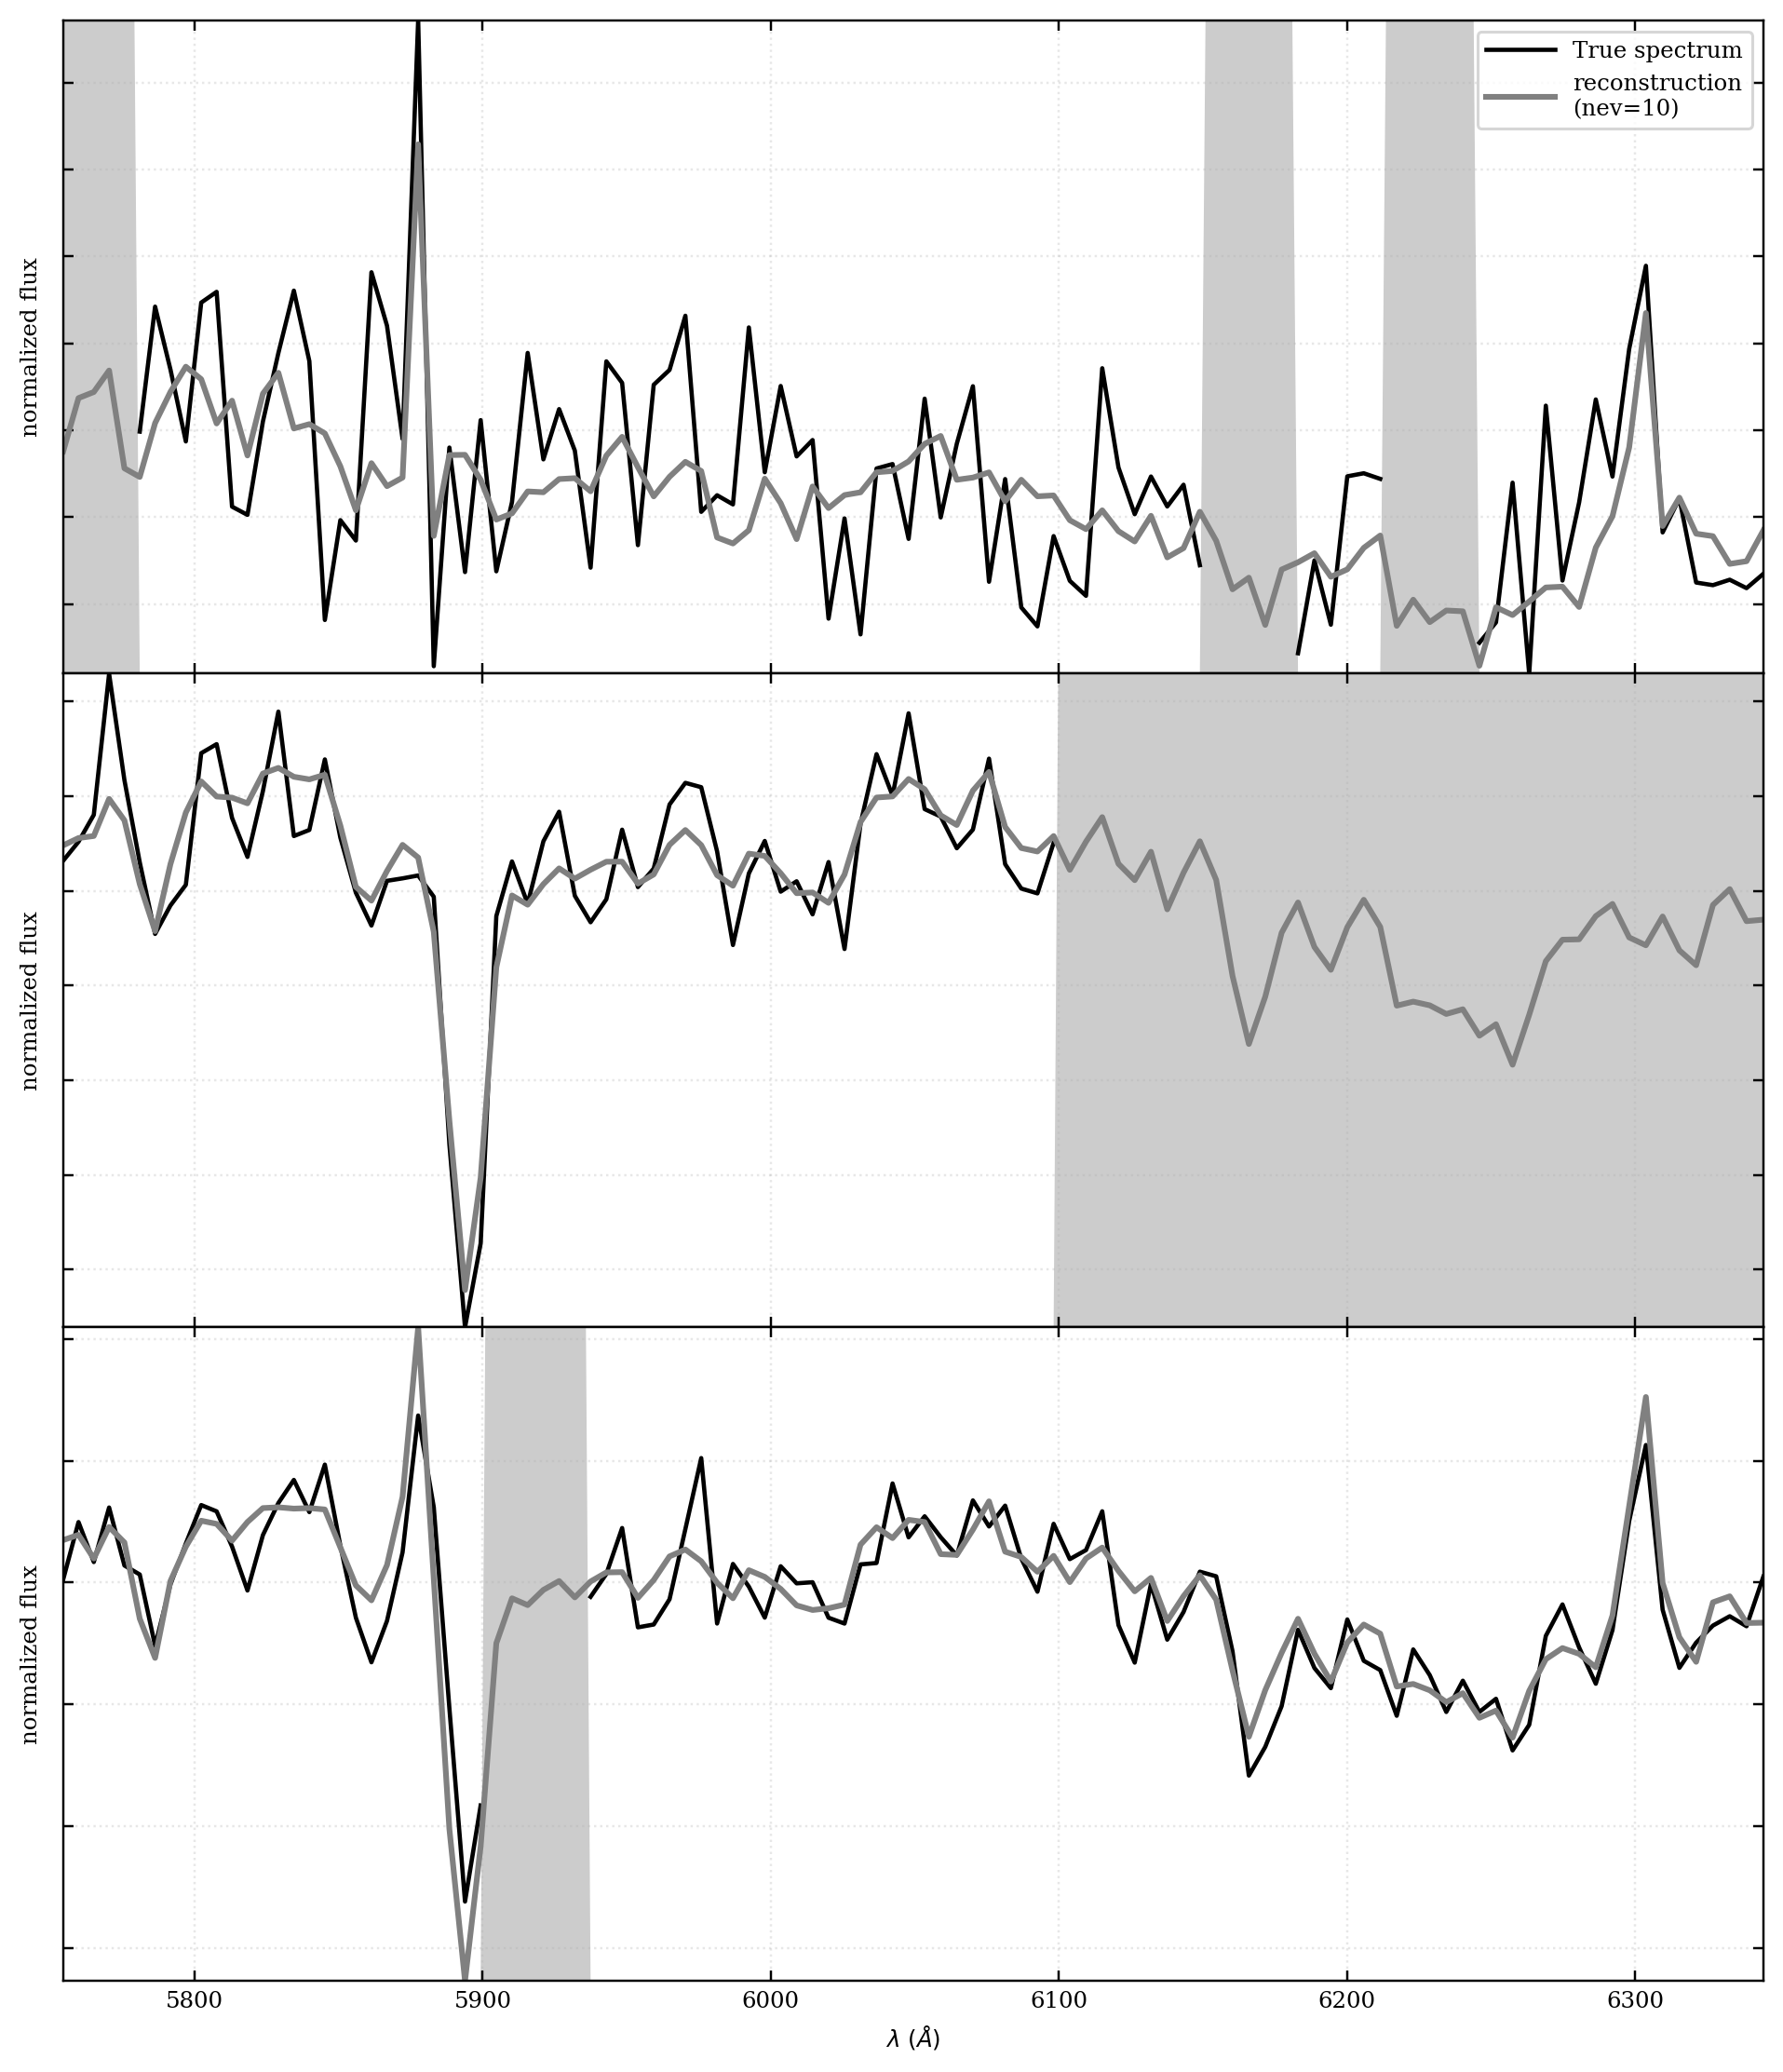

In [9]:
# Author: Jake VanderPlas
# License: BSD
#   The figure produced by this code is published in the textbook
#   "Statistics, Data Mining, and Machine Learning in Astronomy" (2013)
#   For more information, see http://astroML.github.com
#   To report a bug or issue, use the following forum:
#    https://groups.google.com/forum/#!forum/astroml-general
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import ticker

from astroML.datasets import fetch_sdss_corrected_spectra
from astroML.datasets import sdss_corrected_spectra

#----------------------------------------------------------------------
# This function adjusts matplotlib settings for a uniform feel in the textbook.
# Note that with usetex=True, fonts are rendered with LaTeX.  This may
# result in an error if LaTeX is not installed on your system.  In that case,
# you can set usetex to False.
if "setup_text_plots" not in globals():
    from astroML.plotting import setup_text_plots
setup_text_plots(fontsize=8, usetex=False)

#------------------------------------------------------------
# Get spectra and eigenvectors used to reconstruct them
data = fetch_sdss_corrected_spectra()
spec = sdss_corrected_spectra.reconstruct_spectra(data)
lam = sdss_corrected_spectra.compute_wavelengths(data)
evecs = data['evecs']
mu = data['mu']
norms = data['norms']
mask = data['mask']

#------------------------------------------------------------
# plot the results
i_plot = ((lam > 5750) & (lam < 6350))
lam = lam[i_plot]

specnums = [20, 8, 9]
subplots = [311, 312, 313]

fig = plt.figure(figsize=(10, 11))
fig.subplots_adjust(left=0.09, bottom=0.08, hspace=0, right=0.92, top=0.95)

for subplot, i in zip(subplots, specnums):
    ax = fig.add_subplot(subplot)

    # compute eigen-coefficients
    spec_i_centered = spec[i] / norms[i] - mu
    coeffs = np.dot(spec_i_centered, evecs.T)

    # blank out masked regions
    spec_i = spec[i]
    mask_i = mask[i]
    spec_i[mask_i] = np.nan

    # plot the raw masked spectrum
    ax.plot(lam, spec_i[i_plot], '-', color='k',
            label='True spectrum', lw=1.5)

    # plot two levels of reconstruction
    for nev in [10]:
        if nev == 0:
            label = 'mean'
        else:
            label = 'reconstruction\n(nev=%i)' % nev
        spec_i_recons = norms[i] * (mu + np.dot(coeffs[:nev], evecs[:nev]))
        ax.plot(lam, spec_i_recons[i_plot], label=label, color='grey')

    # plot shaded background in masked region
    ylim = ax.get_ylim()
    mask_shade = ylim[0] + mask[i][i_plot].astype(float) * ylim[1]
    plt.fill(np.concatenate([lam[:1], lam, lam[-1:]]),
             np.concatenate([[ylim[0]], mask_shade, [ylim[0]]]),
             lw=0, fc='k', alpha=0.2)

    ax.set_xlim(lam[0], lam[-1])
    ax.set_ylim(ylim)
    ax.yaxis.set_major_formatter(ticker.NullFormatter())

    if subplot == 311:
        ax.legend(loc=1)

    ax.set_xlabel('$\lambda\ (\AA)$')
    ax.set_ylabel('normalized flux')

plt.show()

<a id="12-scaling"></a>
## 12. Scaling to Massive Datasets: Online / Incremental PCA

For upcoming massive surveys like the Vera C. Rubin Observatory (LSST, producing $\sim 20$ TB per night) or DESI (tens of millions of spectra), loading all data into RAM for batch SVD is physically impossible.

### Computational Bottlenecks:
* Batch SVD on an $N \times K$ matrix scales as $\mathcal{O}(N K^2 + K^3)$.
* Storing the covariance matrix requires $\mathcal{O}(K^2)$ memory per core.

### Solution: Online / Incremental PCA
Rather than batch processing, the sample covariance matrix is updated recursively as each new observation $\mathbf{x}_{\text{new}}$ arrives:
$$\boxed{ C_{\text{new}} = \gamma C_{\text{prev}} + (1 - \gamma) \mathbf{x}_{\text{new}} \mathbf{x}_{\text{new}}^T }$$

Where $\gamma \in (0, 1)$ is a learning rate / discount factor. If $r$ eigenvectors $Y_r$ and eigenvalues $D_r$ from the previous step are retained:
$$C_{\text{new}} \approx \gamma Y_r D_r Y_r^T + (1 - \gamma) \mathbf{x}_{\text{new}} \mathbf{x}_{\text{new}}^T$$

Recomputing the SVD of this rank-$(r + 1)$ system takes only $\mathcal{O}(K r^2)$, allowing real-time stream processing and rapid anomaly detection!

---

### 📚 Selected Astronomical Applications of PCA:
* **Interstellar Medium (ISM) & Velocity Fields:** [Padoan et al. (2017) *A&A* 598, A16](https://www.aanda.org/articles/aa/full_html/2017/03/aa29847-16/aa29847-16.html)
* **Chemical Tagging of Stellar Populations:** [De Silva et al. (2013) *A&A* 553, A12](https://www.aanda.org/articles/aa/full_html/2013/05/aa20961-12/aa20961-12.html)
* **Exoplanet Direct Imaging (High-Contrast ADI):** [Amara & Quanz (2012) *MNRAS* 427, 948](https://academic.oup.com/mnras/article/427/2/948/977832)
* **Point Spread Function (PSF) Modeling:** [Soumagnac et al. (2017) *BAAA* 59, 209](https://ui.adsabs.harvard.edu/link_gateway/2017BAAA...59..209S/PUB_PDF)

<a id="13-exercises"></a>
## 13. Hands-On Conceptual Exercises & Key Takeaways

Test your understanding of PCA and dimensionality reduction with these astronomical concept check questions:

<details>
<summary><b>🧠 Question 1: What happens if you forget to mean-center spectral data before PCA?</b> <i>(Click to expand solution)</i></summary>
<div style="padding: 10px; background: rgba(0,0,0,0.03); border-radius: 4px; margin-top: 5px;">
<b>Solution:</b> If the data are not centered, the origin is far from the data cluster. The first principal component will primarily align with the vector from the origin to the dataset centroid $\boldsymbol{\mu}$, simply reflecting overall mean brightness rather than the true direction of maximal internal variance.
</div>
</details>

<details>
<summary><b>🧠 Question 2: Why are singular values squared equal to eigenvalues ($\lambda_i = s_i^2$)?</b> <i>(Click to expand solution)</i></summary>
<div style="padding: 10px; background: rgba(0,0,0,0.03); border-radius: 4px; margin-top: 5px;">
<b>Solution:</b> From $X / \sqrt{N-1} = U \Sigma V^T$, the covariance is $C_X = (U \Sigma V^T)^T (U \Sigma V^T) = V \Sigma U^T U \Sigma V^T = V \Sigma^2 V^T$. Comparing this to the spectral decomposition $C_X = R \Lambda R^T$, because $V$ is orthogonal and $\Sigma^2$ is diagonal, uniqueness of the spectral decomposition guarantees $R = V$ and $\Lambda = \Sigma^2$.
</div>
</details>

<details>
<summary><b>🧠 Question 3: Why does standard PCA fail on broad-line quasar spectra?</b> <i>(Click to expand solution)</i></summary>
<div style="padding: 10px; background: rgba(0,0,0,0.03); border-radius: 4px; margin-top: 5px;">
<b>Solution:</b> PCA assumes the data manifold is a <i>linear</i> hyper-plane. Quasar emission line changes involve varying Doppler widths, line shifts, and asymmetric profiles from relativistic accretion disk geometry. A Doppler width change $f(\lambda / \Delta\lambda)$ is inherently non-linear; expanding it in fixed linear bases requires Taylor-like expansion into many high-order derivatives, requiring $>30$ components. Non-linear techniques (e.g. Kernel PCA, Autoencoders, Manifold Learning) are preferred.
</div>
</details>

<details>
<summary><b>🧠 Question 4: How does Gappy PCA reconstruct missing data without inverting a $K \times K$ matrix?</b> <i>(Click to expand solution)</i></summary>
<div style="padding: 10px; background: rgba(0,0,0,0.03); border-radius: 4px; margin-top: 5px;">
<b>Solution:</b> Because we project onto a truncated subspace of $r$ pre-computed eigenvectors ($r \ll K$), the coupling matrix $M_{ji} = \sum_k w(k) e_j(k) e_i(k)$ is only of size $r \times r$ (typically $r = 5\text{--}10$). Inverting this tiny $r \times r$ matrix is instantaneous and provides exact optimal minimum-variance coefficients $\boldsymbol{\theta}$.
</div>
</details>

---

### 📌 Summary Reference Table: PCA Formulations at a Glance

| Property | Covariance EVD | SVD on Data Matrix | Dual Matrix (Gram) EVD |
| :--- | :--- | :--- | :--- |
| **Matrix decomposed** | $C_X = \frac{X^T X}{N-1}$ ($K \times K$) | $\frac{X}{\sqrt{N-1}}$ ($N \times K$) | $M_X = \frac{X X^T}{N-1}$ ($N \times N$) |
| **Decomposition** | $C_X = R \Lambda R^T$ | $\frac{X}{\sqrt{N-1}} = U \Sigma V^T$ | $M_X = U \Sigma^2 U^T$ |
| **Eigenvalues / Variances** | $\Lambda = \text{diag}(\lambda_1, \dots, \lambda_K)$ | $\Sigma^2 = \text{diag}(s_1^2, \dots, s_K^2)$ | Same non-zero $\lambda_i = s_i^2$ |
| **Principal Components** | Columns of $R$ | Columns of $V$ | Derived via $V = \frac{1}{\sqrt{N-1}} X^T U \Sigma^{-1}$ |
| **Best when** | $N \gg K$ | General, high precision | $K \gg N$ (e.g. few spectra) |